In [62]:
!ls -lh /content

ls: /content: No such file or directory


In [63]:
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

mkdir: /content: Read-only file system
unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.
ls: /content/netflix_data: No such file or directory


In [64]:
!file /content/combined_data_1.txt.zip
!head -n 5 /content/combined_data_1.txt.zip
!ls -lh /content/combined_data_1.txt.zip

/content/combined_data_1.txt.zip: cannot open `/content/combined_data_1.txt.zip' (No such file or directory)
head: /content/combined_data_1.txt.zip: No such file or directory
ls: /content/combined_data_1.txt.zip: No such file or directory


In [65]:
!unzip -t /content/combined_data_1.txt.zip

unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.


In [66]:
!rm -rf /content/netflix_data
!mkdir -p /content/netflix_data
!unzip -q /content/combined_data_1.txt.zip -d /content/netflix_data
!ls -lh /content/netflix_data

mkdir: /content: Read-only file system
unzip:  cannot find or open /content/combined_data_1.txt.zip, /content/combined_data_1.txt.zip.zip or /content/combined_data_1.txt.zip.ZIP.
ls: /content/netflix_data: No such file or directory


In [67]:
ratings_paths = ["../summer26-guard-railing-sensitive-data/data/netflix/combined_data_1.txt",
                 "../summer26-guard-railing-sensitive-data/data/netflix/combined_data_2.txt",
                 "../summer26-guard-railing-sensitive-data/data/netflix/combined_data_3.txt",
                 "../summer26-guard-railing-sensitive-data/data/netflix/combined_data_4.txt"]

ratings_path = "../summer26-guard-railing-sensitive-data/data/netflix/combined_data_1.txt"

titles_path = "../summer26-guard-railing-sensitive-data/data/netflix/movie_titles.csv"

In [68]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

def parse_netflix_file(path, max_rows = None):
    rows = []
    movie_id = None

    input_files = []


    with open(path, "r", encoding="latin1") as f:
        for line in f:
            line = line.strip()

            if line.endswith(":"):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(",")
                rows.append((int(user_id), movie_id, int(rating), date))

                if max_rows is not None and len(rows) >= max_rows:
                    break

    return pd.DataFrame(rows, columns=["user_id", "movie_id", "rating", "date"])

def parse_netflix_files(paths, max_rows=None):
    rows = []

    for path in paths:
        movie_id = None

        with open(path, "r", encoding="latin1") as f:
            for line in f:
                line = line.strip()

                if line.endswith(":"):
                    movie_id = int(line[:-1])
                else:
                    user_id, rating, date = line.split(",")
                    rows.append((int(user_id), movie_id, int(rating), date))

                    if max_rows is not None and len(rows) >= max_rows:
                        return pd.DataFrame(
                            rows,
                            columns=["user_id", "movie_id", "rating", "date"]
                        )

    return pd.DataFrame(rows, columns=["user_id", "movie_id", "rating", "date"])

# New Section

In [69]:
df = parse_netflix_file(ratings_path)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").astype(str)

df["preference"] = np.where(
    df["rating"] >= 4, "liked",
    np.where(df["rating"] <= 2, "disliked", "neutral")
)

print("ratings:", len(df))
print("users:", df["user_id"].nunique())
print("movies:", df["movie_id"].nunique())

df.head()

ratings: 24053764
users: 470758
movies: 4499


,user_id,movie_id,rating,date,month,preference
0,1488844,1,3,2005-09-06,2005-09,neutral
1,822109,1,5,2005-05-13,2005-05,liked
2,885013,1,4,2005-10-19,2005-10,liked
3,30878,1,4,2005-12-26,2005-12,liked
4,823519,1,3,2004-05-03,2004-05,neutral


In [70]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
}

In [71]:
def make_key_from_row(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_index(df, cols):
    # Drop duplicates so a user only appears once per fact
    small = df[cols + ["user_id"]].drop_duplicates()

    # groupby returns scalar keys for one column, tuple keys for multiple columns
    index = small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()
    return index

In [72]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
done


In [73]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [74]:
def candidate_count(known_rows, mode):
    cols = modes_to_cols[mode]
    index = indexes[mode]

    candidates = None

    for _, row in known_rows.iterrows():
        key = make_key_from_row(row, cols)
        matching_users = index.get(key, set())

        if candidates is None:
            candidates = set(matching_users)
        else:
            candidates &= matching_users

    return len(candidates)

In [75]:
eligible_users = [u for u, hist in user_histories.items() if len(hist) >= 2]

target_user = random.choice(eligible_users)
known_rows = user_histories[target_user].sample(2, random_state=0)

print("Target user:", target_user)
display(known_rows)

for mode in modes_to_cols:
    print(mode, "candidate count:", candidate_count(known_rows, mode))

Target user: 1214438


,user_id,movie_id,rating,date,month,preference
18156834,1214438,3451,2,2004-05-24,2004-05,disliked
15071443,1214438,2900,4,2003-12-26,2003-12,liked


movie_only candidate count: 479
movie_rating candidate count: 20
movie_preference candidate count: 25
movie_month candidate count: 1
movie_rating_month candidate count: 1


In [76]:
def run_experiment(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k
                })

    return pd.DataFrame(results)

In [77]:
results = run_experiment(
    n_known_values=[1, 2, 3],
    trials_per_setting=200
)

results.head(15)

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3


,mode,n_known,target_user,candidate_count
0,movie_only,1,1992292,117270
1,movie_only,1,51552,20095
2,movie_only,1,35928,27667
3,movie_only,1,1611646,85050
4,movie_only,1,2237047,42113
5,movie_only,1,756612,71614
6,movie_only,1,734436,6677
7,movie_only,1,1226546,75140
8,movie_only,1,2089886,104632
9,movie_only,1,884567,48877


In [78]:
summary = results.groupby(["mode", "n_known"]).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
).reset_index()

summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less
0,movie_month,1,3222.530,2186.5,0.0,0.5,2.5
1,movie_month,2,373.110,40.5,10.5,24.5,32.0
2,movie_month,3,48.045,2.0,46.0,63.0,69.5
3,movie_only,1,66618.770,57288.5,0.0,0.0,0.0
4,movie_only,2,22450.520,13174.5,0.0,0.0,0.0
5,movie_only,3,9441.900,5256.5,0.0,0.5,2.5
6,movie_preference,1,34933.000,26230.5,0.0,0.0,0.0
7,movie_preference,2,5473.790,2084.0,0.0,1.5,3.0
8,movie_preference,3,1594.135,235.0,2.5,10.5,14.5
9,movie_rating,1,19797.925,12746.5,0.0,0.0,0.0


In [79]:
modes_to_cols = {
    "movie_only": ["movie_id"],
    "movie_rating": ["movie_id", "rating"],
    "movie_preference": ["movie_id", "preference"],
    "movie_month": ["movie_id", "month"],
    "movie_rating_month": ["movie_id", "rating", "month"],
    "movie_date": ["movie_id", "date"],
    "movie_rating_date": ["movie_id", "rating", "date"],
}

In [80]:
indexes = {}

for mode, cols in modes_to_cols.items():
    print("building:", mode)
    indexes[mode] = build_index(df, cols)

print("done")

building: movie_only
building: movie_rating
building: movie_preference
building: movie_month
building: movie_rating_month
building: movie_date
building: movie_rating_date
done


In [81]:
movie_popularity = df.groupby("movie_id")["user_id"].nunique().rename("movie_popularity")
movie_info = movie_popularity.reset_index()

movie_info["popularity_bucket"] = pd.qcut(
    movie_info["movie_popularity"].rank(method="first"),
    q=4,
    labels=["rare", "less_common", "common", "popular"]
)

df = df.merge(movie_info, on="movie_id", how="left")
df.head()

,user_id,movie_id,rating,date,month,preference,movie_popularity,popularity_bucket
0,1488844,1,3,2005-09-06,2005-09,neutral,547,less_common
1,822109,1,5,2005-05-13,2005-05,liked,547,less_common
2,885013,1,4,2005-10-19,2005-10,liked,547,less_common
3,30878,1,4,2005-12-26,2005-12,liked,547,less_common
4,823519,1,3,2004-05-03,2004-05,neutral,547,less_common


In [82]:
user_histories = {
    user_id: group
    for user_id, group in df.groupby("user_id")
}

In [83]:
def run_experiment_with_features(n_known_values=[1, 2, 3], trials_per_setting=200):
    results = []

    user_counts = df["user_id"].value_counts()

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for mode in modes_to_cols:
            print(f"Running mode={mode}, n_known={n_known}")

            for _ in range(trials_per_setting):
                target_user = random.choice(eligible_users)
                history = user_histories[target_user]

                known_rows = history.sample(n_known)
                k = candidate_count(known_rows, mode)

                rarest_row = known_rows.sort_values("movie_popularity").iloc[0]

                results.append({
                    "mode": mode,
                    "n_known": n_known,
                    "target_user": target_user,
                    "candidate_count": k,

                    "avg_movie_popularity": known_rows["movie_popularity"].mean(),
                    "min_movie_popularity": known_rows["movie_popularity"].min(),
                    "rarest_movie_bucket": rarest_row["popularity_bucket"],

                    "avg_rating": known_rows["rating"].mean(),
                    "min_rating": known_rows["rating"].min(),
                    "max_rating": known_rows["rating"].max(),
                    "has_low_rating": (known_rows["rating"] <= 2).any(),
                    "has_high_rating": (known_rows["rating"] >= 4).any(),
                })

    return pd.DataFrame(results)

In [84]:
results2 = run_experiment_with_features(
    n_known_values=[1, 2, 3],
    trials_per_setting=300
)

results2.head()

Running mode=movie_only, n_known=1
Running mode=movie_rating, n_known=1
Running mode=movie_preference, n_known=1
Running mode=movie_month, n_known=1
Running mode=movie_rating_month, n_known=1
Running mode=movie_date, n_known=1
Running mode=movie_rating_date, n_known=1
Running mode=movie_only, n_known=2
Running mode=movie_rating, n_known=2
Running mode=movie_preference, n_known=2
Running mode=movie_month, n_known=2
Running mode=movie_rating_month, n_known=2
Running mode=movie_date, n_known=2
Running mode=movie_rating_date, n_known=2
Running mode=movie_only, n_known=3
Running mode=movie_rating, n_known=3
Running mode=movie_preference, n_known=3
Running mode=movie_month, n_known=3
Running mode=movie_rating_month, n_known=3
Running mode=movie_date, n_known=3
Running mode=movie_rating_date, n_known=3


,mode,n_known,target_user,candidate_count,avg_movie_popularity,min_movie_popularity,rarest_movie_bucket,avg_rating,min_rating,max_rating,has_low_rating,has_high_rating
0,movie_only,1,505258,118413,118413.0,118413,popular,1.0,1,1,True,False
1,movie_only,1,2085486,75148,75148.0,75148,popular,4.0,4,4,False,True
2,movie_only,1,1971311,139428,139428.0,139428,popular,4.0,4,4,False,True
3,movie_only,1,1970935,18446,18446.0,18446,popular,4.0,4,4,False,True
4,movie_only,1,2365408,98720,98720.0,98720,popular,5.0,5,5,False,True


In [85]:
rare_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "rarest_movie_bucket"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

rare_summary

,n_known,rarest_movie_bucket,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,common,23.000000,15.0,0.000000,10.000000,20
1,1,less_common,5.833333,5.5,0.000000,50.000000,6
2,1,popular,1138.213235,656.0,0.000000,0.000000,272
3,1,rare,5.000000,5.0,0.000000,50.000000,2
4,2,common,1.285714,1.0,71.428571,100.000000,28
5,2,less_common,1.000000,1.0,100.000000,100.000000,9
6,2,popular,33.257692,5.0,26.153846,51.538462,260
7,2,rare,1.000000,1.0,100.000000,100.000000,3
8,3,common,1.000000,1.0,100.000000,100.000000,36
9,3,less_common,1.000000,1.0,100.000000,100.000000,9


In [86]:
low_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_low_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

low_rating_summary

,n_known,has_low_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,1122.456929,643.0,0.000000,0.749064,267
1,1,True,315.242424,150.0,0.000000,12.121212,33
2,2,False,34.360870,4.0,28.695652,53.913043,230
3,2,True,11.314286,2.0,48.571429,71.428571,70
4,3,False,3.396040,1.0,71.287129,89.108911,202
5,3,True,1.387755,1.0,88.775510,97.959184,98


In [87]:
high_rating_summary = (
    results2[results2["mode"] == "movie_rating_month"]
    .groupby(["n_known", "has_high_rating"])
    .agg(
        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),
        pct_unique=("candidate_count", lambda x: (x == 1).mean() * 100),
        pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
        count=("candidate_count", "size"),
    )
    .reset_index()
)

high_rating_summary

,n_known,has_high_rating,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,count
0,1,False,759.983051,376.0,0.000000,4.237288,118
1,1,True,1211.104396,649.5,0.000000,0.549451,182
2,2,False,18.692308,3.0,26.923077,59.615385,52
3,2,True,31.141129,3.0,34.677419,57.661290,248
4,3,False,1.555556,1.0,77.777778,100.000000,27
5,3,True,2.857143,1.0,76.923077,91.208791,273


In [88]:
baseline_summary = summary.copy()
baseline_summary["dataset_version"] = "original_non_anonymized"

baseline_summary

,mode,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,dataset_version
0,movie_month,1,3222.530,2186.5,0.0,0.5,2.5,original_non_anonymized
1,movie_month,2,373.110,40.5,10.5,24.5,32.0,original_non_anonymized
2,movie_month,3,48.045,2.0,46.0,63.0,69.5,original_non_anonymized
3,movie_only,1,66618.770,57288.5,0.0,0.0,0.0,original_non_anonymized
4,movie_only,2,22450.520,13174.5,0.0,0.0,0.0,original_non_anonymized
5,movie_only,3,9441.900,5256.5,0.0,0.5,2.5,original_non_anonymized
6,movie_preference,1,34933.000,26230.5,0.0,0.0,0.0,original_non_anonymized
7,movie_preference,2,5473.790,2084.0,0.0,1.5,3.0,original_non_anonymized
8,movie_preference,3,1594.135,235.0,2.5,10.5,14.5,original_non_anonymized
9,movie_rating,1,19797.925,12746.5,0.0,0.0,0.0,original_non_anonymized


In [89]:
baseline_summary.to_csv("baseline_non_anonymized_summary.csv", index=False)

In [90]:
# from google.colab import files
# files.download("baseline_non_anonymized_summary.csv")

In [91]:
import pandas as pd
import numpy as np
import random

In [92]:
def make_releases(df):
    releases = []

    # Original-ish release
    releases.append({
        "name": "original_movie_rating_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating", "month"]
    })

    # Defense 1: remove month
    releases.append({
        "name": "remove_month",
        "data": df.copy(),
        "cols": ["movie_id", "rating"]
    })

    # Defense 2: coarsen rating
    releases.append({
        "name": "coarsen_rating_to_preference",
        "data": df.copy(),
        "cols": ["movie_id", "preference", "month"]
    })

    # Defense 3: remove month and coarsen rating
    releases.append({
        "name": "remove_month_and_coarsen_rating",
        "data": df.copy(),
        "cols": ["movie_id", "preference"]
    })

    # Defense 4: movie only
    releases.append({
        "name": "movie_only",
        "data": df.copy(),
        "cols": ["movie_id"]
    })

    # Defense 5: remove rare movies
    movie_counts = df.groupby("movie_id")["user_id"].nunique()
    common_movies = movie_counts[movie_counts >= 500].index

    df_no_rare = df[df["movie_id"].isin(common_movies)].copy()

    releases.append({
        "name": "remove_rare_movies_min_500_users",
        "data": df_no_rare,
        "cols": ["movie_id", "rating", "month"]
    })

    return releases

In [93]:
def build_index_for_cols(data, cols):
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def candidate_count_for_rows(known_rows, cols, index):
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

    return len(candidates)


def evaluate_release(data, release_name, cols, n_known_values=[1, 2, 3], trials=300):
    index = build_index_for_cols(data, cols)

    user_histories = {
        user_id: group
        for user_id, group in data.groupby("user_id")
    }

    user_counts = data["user_id"].value_counts()
    results = []

    for n_known in n_known_values:
        eligible_users = user_counts[user_counts >= n_known].index.tolist()

        for _ in range(trials):
            target_user = random.choice(eligible_users)
            history = user_histories[target_user]

            known_rows = history.sample(n_known)
            k = candidate_count_for_rows(known_rows, cols, index)

            results.append({
                "release_name": release_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": k,
                "unique": k == 1,
                "surety_pct": 100 / k if k > 0 else 0,
            })

    return pd.DataFrame(results)

In [94]:
releases = make_releases(df)

all_results = []

for release in releases:
    print("Evaluating:", release["name"])
    result = evaluate_release(
        data=release["data"],
        release_name=release["name"],
        cols=release["cols"],
        n_known_values=[1, 2, 3],
        trials=300
    )
    all_results.append(result)

all_results = pd.concat(all_results, ignore_index=True)

all_results.head(15)

Evaluating: original_movie_rating_month
Evaluating: remove_month
Evaluating: coarsen_rating_to_preference
Evaluating: remove_month_and_coarsen_rating
Evaluating: movie_only
Evaluating: remove_rare_movies_min_500_users


,release_name,knowledge_cols,n_known,target_user,candidate_count,unique,surety_pct
0,original_movie_rating_month,movie_id + rating + month,1,2244618,335,False,0.298507
1,original_movie_rating_month,movie_id + rating + month,1,2283173,1242,False,0.080515
2,original_movie_rating_month,movie_id + rating + month,1,1574119,1,True,100.000000
3,original_movie_rating_month,movie_id + rating + month,1,609301,38,False,2.631579
4,original_movie_rating_month,movie_id + rating + month,1,253798,4275,False,0.023392
5,original_movie_rating_month,movie_id + rating + month,1,2531166,1690,False,0.059172
6,original_movie_rating_month,movie_id + rating + month,1,2384870,2633,False,0.037979
7,original_movie_rating_month,movie_id + rating + month,1,1598331,2231,False,0.044823
8,original_movie_rating_month,movie_id + rating + month,1,1049786,235,False,0.425532
9,original_movie_rating_month,movie_id + rating + month,1,1999043,11218,False,0.008914


In [95]:
evaluation_summary = all_results.groupby(
    ["release_name", "knowledge_cols", "n_known"]
).agg(
    avg_candidate_size=("candidate_count", "mean"),
    median_candidate_size=("candidate_count", "median"),
    pct_unique=("unique", lambda x: x.mean() * 100),
    pct_5_or_less=("candidate_count", lambda x: (x <= 5).mean() * 100),
    pct_10_or_less=("candidate_count", lambda x: (x <= 10).mean() * 100),
    avg_surety_pct=("surety_pct", "mean"),
    median_surety_pct=("surety_pct", "median"),
).reset_index()

evaluation_summary

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct
0,coarsen_rating_to_preference,movie_id + preference + month,1,1875.520000,761.0,1.000000,2.666667,4.000000,2.299762,0.131472
1,coarsen_rating_to_preference,movie_id + preference + month,2,68.473333,7.0,21.666667,45.000000,54.666667,33.078611,14.285714
2,coarsen_rating_to_preference,movie_id + preference + month,3,15.370000,1.0,67.000000,82.666667,88.333333,74.525639,100.000000
3,movie_only,movie_id,1,63703.563333,53290.5,0.000000,0.000000,0.000000,0.017470,0.001877
4,movie_only,movie_id,2,24596.066667,17702.0,0.000000,0.000000,0.333333,0.189151,0.005649
5,movie_only,movie_id,3,8258.070000,2542.5,0.000000,0.000000,0.666667,0.572612,0.039337
6,original_movie_rating_month,movie_id + rating + month,1,1315.606667,754.0,0.666667,1.666667,3.000000,1.895888,0.132634
7,original_movie_rating_month,movie_id + rating + month,2,31.470000,4.0,29.666667,53.000000,61.333333,41.042618,25.000000
8,original_movie_rating_month,movie_id + rating + month,3,2.893333,1.0,78.000000,93.333333,95.666667,84.866402,100.000000
9,remove_month,movie_id + rating,1,19553.496667,14223.0,0.000000,0.000000,0.000000,0.086147,0.007031


In [96]:
plot_df = evaluation_summary.copy()

pretty_names = {
    "original_movie_rating_month": "Original: movie + rating + month",
    "remove_month": "Remove month",
    "coarsen_rating_to_preference": "Coarsen rating",
    "remove_month_and_coarsen_rating": "Remove month + coarsen rating",
    "movie_only": "Movie only",
    "remove_rare_movies_min_500_users": "Remove rare movies",
}

plot_df["release_label"] = plot_df["release_name"].map(pretty_names)

release_order = [
    "Original: movie + rating + month",
    "Remove month",
    "Coarsen rating",
    "Remove month + coarsen rating",
    "Movie only",
    "Remove rare movies",
]

plot_df["release_label"] = pd.Categorical(
    plot_df["release_label"],
    categories=release_order,
    ordered=True
)

plot_df = plot_df.sort_values(["n_known", "release_label"])
plot_df.head()

,release_name,knowledge_cols,n_known,avg_candidate_size,median_candidate_size,pct_unique,pct_5_or_less,pct_10_or_less,avg_surety_pct,median_surety_pct,release_label
6,original_movie_rating_month,movie_id + rating + month,1,1315.606667,754.0,0.666667,1.666667,3.0,1.895888,0.132634,Original: movie + rating + month
9,remove_month,movie_id + rating,1,19553.496667,14223.0,0.000000,0.000000,0.0,0.086147,0.007031,Remove month
0,coarsen_rating_to_preference,movie_id + preference + month,1,1875.520000,761.0,1.000000,2.666667,4.0,2.299762,0.131472,Coarsen rating
12,remove_month_and_coarsen_rating,movie_id + preference,1,34230.586667,24875.5,0.000000,0.000000,0.0,0.035884,0.004020,Remove month + coarsen rating
3,movie_only,movie_id,1,63703.563333,53290.5,0.000000,0.000000,0.0,0.017470,0.001877,Movie only


In [97]:
table3 = plot_df[plot_df["n_known"] == 3][[
    "release_label",
    "knowledge_cols",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_5_or_less",
    "pct_10_or_less",
    "avg_surety_pct"
]].copy()

table3 = table3.rename(columns={
    "release_label": "Released data version",
    "knowledge_cols": "Attacker knowledge",
    "median_candidate_size": "Median candidate size",
    "avg_candidate_size": "Average candidate size",
    "pct_unique": "% uniquely identified",
    "pct_5_or_less": "% ≤ 5 candidates",
    "pct_10_or_less": "% ≤ 10 candidates",
    "avg_surety_pct": "Average surety %"
})

table3.style.format({
    "Median candidate size": "{:.1f}",
    "Average candidate size": "{:.1f}",
    "% uniquely identified": "{:.1f}%",
    "% ≤ 5 candidates": "{:.1f}%",
    "% ≤ 10 candidates": "{:.1f}%",
    "Average surety %": "{:.1f}%"
})

,Released data version,Attacker knowledge,Median candidate size,Average candidate size,% uniquely identified,% ≤ 5 candidates,% ≤ 10 candidates,Average surety %
8,Original: movie + rating + month,movie_id + rating + month,1.0,2.9,78.0%,93.3%,95.7%,84.9%
11,Remove month,movie_id + rating,53.0,298.8,10.7%,23.7%,30.7%,17.4%
2,Coarsen rating,movie_id + preference + month,1.0,15.4,67.0%,82.7%,88.3%,74.5%
14,Remove month + coarsen rating,movie_id + preference,289.0,1366.7,2.7%,7.0%,10.7%,5.6%
5,Movie only,movie_id,2542.5,8258.1,0.0%,0.0%,0.7%,0.6%
17,Remove rare movies,movie_id + rating + month,1.0,4.0,76.0%,91.3%,94.3%,82.7%


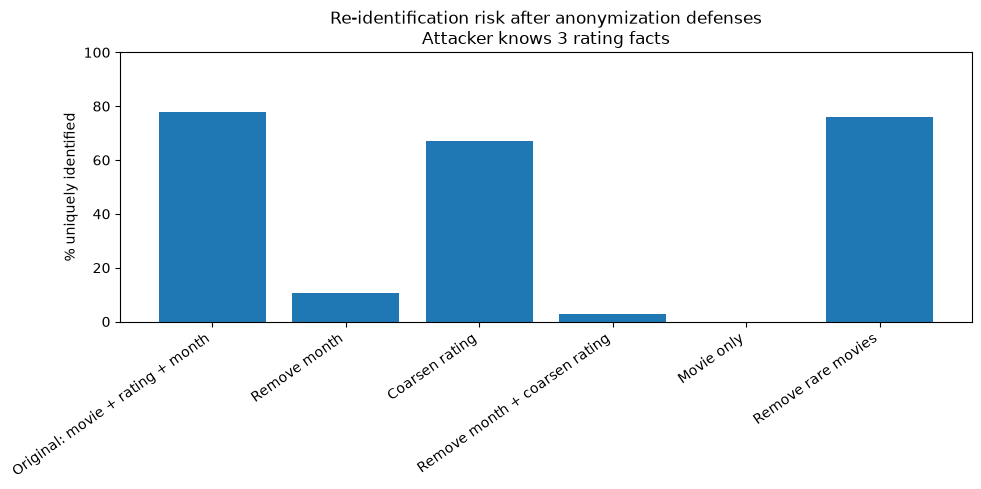

In [98]:
import matplotlib.pyplot as plt

chart_df = plot_df[plot_df["n_known"] == 3].sort_values("release_label")

plt.figure(figsize=(10, 5))
plt.bar(chart_df["release_label"].astype(str), chart_df["pct_unique"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("% uniquely identified")
plt.title("Re-identification risk after anonymization defenses\nAttacker knows 3 rating facts")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [99]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df_attack = df.copy()

if "date" in df_attack.columns:
    df_attack["date"] = pd.to_datetime(df_attack["date"])
    df_attack["year"] = df_attack["date"].dt.year

# Drop date/month from the actual attack dataframe.
df_attack = df_attack[["user_id", "movie_id", "rating", "year"]].copy()

df_attack["user_id"] = df_attack["user_id"].astype(int)
df_attack["movie_id"] = df_attack["movie_id"].astype(int)
df_attack["rating"] = df_attack["rating"].astype(int)
df_attack["year"] = df_attack["year"].astype(int)

print("ratings:", len(df_attack))
print("users:", df_attack["user_id"].nunique())
print("movies:", df_attack["movie_id"].nunique())
print("years:", sorted(df_attack["year"].unique()))

df_attack.head()

ratings: 24053764
users: 470758
movies: 4499
years: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)]


,user_id,movie_id,rating,year
0,1488844,1,3,2005
1,822109,1,5,2005
2,885013,1,4,2005
3,30878,1,4,2005
4,823519,1,3,2004


In [100]:
# Attacker knowledge modes with NO date/month.
# The second one keeps year, which is much weaker than month/date but still temporal.

KNOWLEDGE_MODES_NO_MONTH = {
    "movie_rating_no_time": ["movie_id", "rating"],
    "movie_rating_year": ["movie_id", "rating", "year"],
}


def random_different_values(original_values, pool, rng, p = None):
    """
    Replace each value by a random DIFFERENT value from pool.
    """

    original_values = np.asarray(original_values)
    pool = np.asarray(pool)

    if len(pool) <= 1:
        return original_values.copy()
    

    new_values = rng.choice(pool, size=len(original_values), p = p)
    same = new_values == original_values

    while same.any():
        new_values[same] = rng.choice(pool, size=same.sum(), p = p)
        same = new_values == original_values

    return new_values


def make_noisy_release(
    clean_data,
    rating_p=0.0,
    movie_p=0.0,
    user_p=0.0,
    seed=0,
    weighted_sampling = False
):
    """
    Create a noisy released dataset.

    rating_p: probability that a row's rating is changed to a different rating.
    movie_p: probability that a row's movie_id is changed to a different movie_id.
    user_p: probability that a row's user_id is changed to a different user_id.

    This is row-level noise.
    """
    rng = np.random.default_rng(seed)
    released = clean_data.copy()

    n = len(released)


    # Precompute pools and probabilities if needed
    rating_pool = [1,2,3,4,5]
    movie_pool = clean_data["movie_id"].unique()
    user_pool = clean_data["user_id"].unique()

    rating_probs = None
    movie_probs = None
    user_probs = None


    if weighted_sampling:
        rating_counts = clean_data["rating"].value_counts(sort=False)
        rating_pool = rating_counts.index.to_numpy()
        rating_probs = (rating_counts / rating_counts.sum()).to_numpy()

        movie_counts = clean_data["movie_id"].value_counts(sort=False)
        movie_pool = movie_counts.index.to_numpy()
        movie_probs = (movie_counts / movie_counts.sum()).to_numpy()

        user_counts = clean_data["user_id"].value_counts(sort=False)
        user_pool = user_counts.index.to_numpy()
        user_probs = (user_counts / user_counts.sum()).to_numpy()

        


    # Flip rating with probability rating_p
    if rating_p > 0:
        mask = rng.random(n) < rating_p
        released.loc[mask, "rating"] = random_different_values(
            released.loc[mask, "rating"].to_numpy(),
            pool=rating_pool,
            p = rating_probs,
            rng=rng
        )

    # Change movie_id with probability movie_p
    if movie_p > 0:
        mask = rng.random(n) < movie_p
        released.loc[mask, "movie_id"] = random_different_values(
            released.loc[mask, "movie_id"].to_numpy(),
            pool= movie_pool,
            p = movie_probs,
            rng=rng
        )

        

    # Change user_id / pseudonym with probability user_p
    if user_p > 0:
        mask = rng.random(n) < user_p
        released.loc[mask, "user_id"] = random_different_values(
            released.loc[mask, "user_id"].to_numpy(),
            pool= user_pool,
            p = user_probs,
            rng=rng
        )

    return released




def row_key(row, cols):
    values = tuple(row[c] for c in cols)
    return values[0] if len(values) == 1 else values


def build_user_index(data, cols):
    """
    Maps each fact, e.g. (movie_id, rating), to the set of users having that fact.
    """
    small = data[cols + ["user_id"]].drop_duplicates()
    return small.groupby(cols)["user_id"].agg(lambda x: set(x)).to_dict()


def candidate_set_for_rows(known_rows, cols, index):
    """
    Return the set of released users matching all known facts.
    """
    candidates = None

    for _, row in known_rows.iterrows():
        key = row_key(row, cols)
        matching = index.get(key, set())

        if candidates is None:
            candidates = set(matching)
        else:
            candidates &= matching

        if len(candidates) == 0:
            break

    return candidates if candidates is not None else set()

In [101]:
# Histories are sampled from the TRUE clean data.
# The index is built from the NOISY released data.

clean_user_histories = {
    user_id: group
    for user_id, group in df_attack.groupby("user_id")
}

clean_user_counts = df_attack["user_id"].value_counts()


def evaluate_noisy_release(
    clean_data,
    released_data,
    scenario_name,
    p,
    knowledge_name,
    cols,
    n_known_values=[1, 2, 3, 4],
    trials=300,
    candidate_cutoff=5,
    seed=0
):
    """
    candidate_cutoff=5 means we count k < 5, i.e. 1,2,3,4 candidates.

    False positive among k < 5:
    candidate set is nonempty and has size < 5, but target_user is not in it.
    """
    rng = np.random.default_rng(seed)

    index = build_user_index(released_data, cols)

    results = []

    for n_known in n_known_values:
        eligible_users = clean_user_counts[clean_user_counts >= n_known].index.to_numpy()

        for _ in range(trials):
            target_user = int(rng.choice(eligible_users))
            history = clean_user_histories[target_user]

            known_rows = history.sample(
                n_known,
                random_state=int(rng.integers(0, 2**32 - 1))
            )

            candidates = candidate_set_for_rows(known_rows, cols, index)
            candidate_count = len(candidates)

            true_user_in_candidates = target_user in candidates

            less_than_5_candidates = (candidate_count > 0) and (candidate_count < candidate_cutoff)
            less_than_5_correct = less_than_5_candidates and true_user_in_candidates
            less_than_5_wrong = less_than_5_candidates and (not true_user_in_candidates)

            unique = candidate_count == 1
            unique_correct = unique and true_user_in_candidates
            unique_wrong = unique and (not true_user_in_candidates)

            results.append({
                "scenario": scenario_name,
                "p": p,
                "knowledge_name": knowledge_name,
                "knowledge_cols": " + ".join(cols),
                "n_known": n_known,
                "target_user": target_user,
                "candidate_count": candidate_count,

                "true_user_in_candidates": true_user_in_candidates,

                "less_than_5_candidates": less_than_5_candidates,
                "less_than_5_correct": less_than_5_correct,
                "less_than_5_wrong": less_than_5_wrong,

                "unique": unique,
                "unique_correct": unique_correct,
                "unique_wrong": unique_wrong,

                "no_match": candidate_count == 0,
            })

    return pd.DataFrame(results)


def summarize_noisy_results(results):
    summary = results.groupby(
        ["scenario", "p", "knowledge_name", "knowledge_cols", "n_known"]
    ).agg(
        trials=("candidate_count", "size"),

        avg_candidate_size=("candidate_count", "mean"),
        median_candidate_size=("candidate_count", "median"),

        pct_unique=("unique", lambda x: x.mean() * 100),
        pct_unique_correct=("unique_correct", lambda x: x.mean() * 100),
        pct_unique_wrong=("unique_wrong", lambda x: x.mean() * 100),

        pct_less_than_5_candidates=("less_than_5_candidates", lambda x: x.mean() * 100),
        pct_less_than_5_correct=("less_than_5_correct", lambda x: x.mean() * 100),
        pct_less_than_5_wrong=("less_than_5_wrong", lambda x: x.mean() * 100),

        pct_no_match=("no_match", lambda x: x.mean() * 100),

        less_than_5_count=("less_than_5_candidates", "sum"),
        less_than_5_wrong_count=("less_than_5_wrong", "sum"),
        unique_count=("unique", "sum"),
        unique_wrong_count=("unique_wrong", "sum"),
    ).reset_index()

    summary["false_positive_rate_among_less_than_5"] = (
        100 * summary["less_than_5_wrong_count"] / summary["less_than_5_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_unique"] = (
        100 * summary["unique_wrong_count"] / summary["unique_count"].replace(0, np.nan)
    )

    summary["false_positive_rate_among_less_than_5"] = summary["false_positive_rate_among_less_than_5"].fillna(0)
    summary["false_positive_rate_among_unique"] = summary["false_positive_rate_among_unique"].fillna(0)

    return summary

In [102]:
p_values = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]
trials = 300
n_known_values = [1, 2, 3, 4]
weighted_samplings = False

noise_scenarios = [
    "rating_noise",
    "movie_noise",
    "user_id_noise",
    "all_three_noise",
]

all_noise_results = []

base_seed = 12345
run_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Making release:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        released_data = make_noisy_release(
            df_attack,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=base_seed + run_counter,
            weighted_sampling= weighted_samplings
        )

        for knowledge_name, cols in KNOWLEDGE_MODES_NO_MONTH.items():
            print("  Evaluating:", knowledge_name)

            result = evaluate_noisy_release(
                clean_data=df_attack,
                released_data=released_data,
                scenario_name=scenario,
                p=p,
                knowledge_name=knowledge_name,
                cols=cols,
                n_known_values=n_known_values,
                trials=trials,
                candidate_cutoff=5,
                seed=base_seed + 10_000 + run_counter
            )

            all_noise_results.append(result)
            run_counter += 1

all_noise_results = pd.concat(all_noise_results, ignore_index=True)

noise_summary = summarize_noisy_results(all_noise_results)

noise_summary.head(20)

Making release: rating_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.05
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.1
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: rating_noise p = 0.2
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.0
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.01
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.02
  Evaluating: movie_rating_no_time
  Evaluating: movie_rating_year
Making release: movie_noise p = 0.05
  Evaluating: movie_ratin

,scenario,p,knowledge_name,knowledge_cols,n_known,trials,avg_candidate_size,median_candidate_size,pct_unique,pct_unique_correct,...,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,pct_no_match,less_than_5_count,less_than_5_wrong_count,unique_count,unique_wrong_count,false_positive_rate_among_less_than_5,false_positive_rate_among_unique
0,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,1,300,22176.833333,14156.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
1,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,2,300,2040.306667,918.5,1.333333,1.333333,...,5.000000,5.000000,0.000000,0.000000,15,0,4,0,0.000000,0.000000
2,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,3,300,309.993333,77.0,7.666667,7.666667,...,14.666667,14.666667,0.000000,0.000000,44,0,23,0,0.000000,0.000000
3,all_three_noise,0.00,movie_rating_no_time,movie_id + rating,4,300,43.996667,7.0,23.333333,23.333333,...,41.666667,41.666667,0.000000,0.000000,125,0,70,0,0.000000,0.000000
4,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,1,300,8753.590000,4821.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
5,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,2,300,705.253333,180.0,4.666667,4.666667,...,12.666667,12.666667,0.000000,0.000000,38,0,14,0,0.000000,0.000000
6,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,3,300,90.640000,13.5,19.000000,19.000000,...,33.333333,33.333333,0.000000,0.000000,100,0,57,0,0.000000,0.000000
7,all_three_noise,0.00,movie_rating_year,movie_id + rating + year,4,300,12.710000,1.0,50.666667,50.666667,...,69.000000,69.000000,0.000000,0.000000,207,0,152,0,0.000000,0.000000
8,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,1,300,20833.716667,14307.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000
9,all_three_noise,0.01,movie_rating_no_time,movie_id + rating,2,300,1979.470000,733.5,0.666667,0.666667,...,1.000000,1.000000,0.000000,0.333333,3,0,2,0,0.000000,0.000000


In [103]:
# Main table: attacker knows 3 or 4 facts, and we track k < 5.

main_noise_table = noise_summary[
    noise_summary["n_known"].isin([3, 4])
].copy()

main_noise_table = main_noise_table[[
    "scenario",
    "p",
    "knowledge_name",
    "n_known",
    "median_candidate_size",
    "avg_candidate_size",
    "pct_unique",
    "pct_unique_correct",
    "pct_unique_wrong",
    "pct_less_than_5_candidates",
    "pct_less_than_5_correct",
    "pct_less_than_5_wrong",
    "false_positive_rate_among_less_than_5",
    "pct_no_match",
]]

main_noise_table = main_noise_table.sort_values(
    ["knowledge_name", "n_known", "scenario", "p"]
)

main_noise_table.style.format({
    "p": "{:.2f}",
    "median_candidate_size": "{:.1f}",
    "avg_candidate_size": "{:.1f}",
    "pct_unique": "{:.1f}%",
    "pct_unique_correct": "{:.1f}%",
    "pct_unique_wrong": "{:.1f}%",
    "pct_less_than_5_candidates": "{:.1f}%",
    "pct_less_than_5_correct": "{:.1f}%",
    "pct_less_than_5_wrong": "{:.1f}%",
    "false_positive_rate_among_less_than_5": "{:.1f}%",
    "pct_no_match": "{:.1f}%",
})

,scenario,p,knowledge_name,n_known,median_candidate_size,avg_candidate_size,pct_unique,pct_unique_correct,pct_unique_wrong,pct_less_than_5_candidates,pct_less_than_5_correct,pct_less_than_5_wrong,false_positive_rate_among_less_than_5,pct_no_match
2,all_three_noise,0.00,movie_rating_no_time,3,77.0,310.0,7.7%,7.7%,0.0%,14.7%,14.7%,0.0%,0.0%,0.0%
10,all_three_noise,0.01,movie_rating_no_time,3,86.5,278.1,5.7%,5.7%,0.0%,14.3%,13.0%,1.3%,9.3%,0.3%
18,all_three_noise,0.02,movie_rating_no_time,3,58.5,255.0,9.0%,8.3%,0.7%,17.3%,15.3%,2.0%,11.5%,0.3%
26,all_three_noise,0.05,movie_rating_no_time,3,50.5,235.8,7.0%,4.7%,2.3%,17.7%,10.7%,7.0%,39.6%,2.3%
34,all_three_noise,0.10,movie_rating_no_time,3,38.5,154.1,9.0%,5.0%,4.0%,16.0%,8.0%,8.0%,50.0%,4.3%
42,all_three_noise,0.20,movie_rating_no_time,3,26.5,77.5,6.7%,1.3%,5.3%,17.0%,2.7%,14.3%,84.3%,7.7%
50,movie_noise,0.00,movie_rating_no_time,3,70.0,299.6,6.7%,6.7%,0.0%,16.3%,16.3%,0.0%,0.0%,0.0%
58,movie_noise,0.01,movie_rating_no_time,3,47.5,297.1,12.0%,12.0%,0.0%,25.0%,25.0%,0.0%,0.0%,0.3%
66,movie_noise,0.02,movie_rating_no_time,3,79.0,309.1,5.7%,5.0%,0.7%,13.3%,12.7%,0.7%,5.0%,1.0%
74,movie_noise,0.05,movie_rating_no_time,3,55.0,214.7,7.3%,7.0%,0.3%,15.0%,13.3%,1.7%,11.1%,1.3%


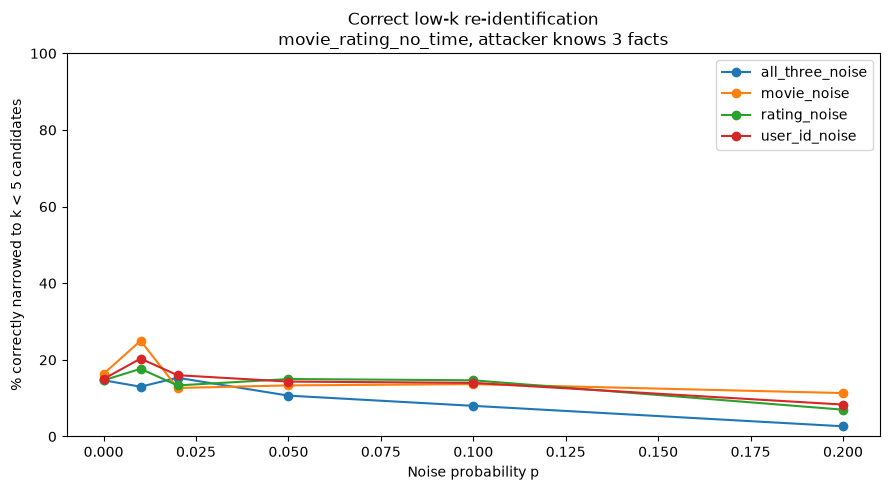

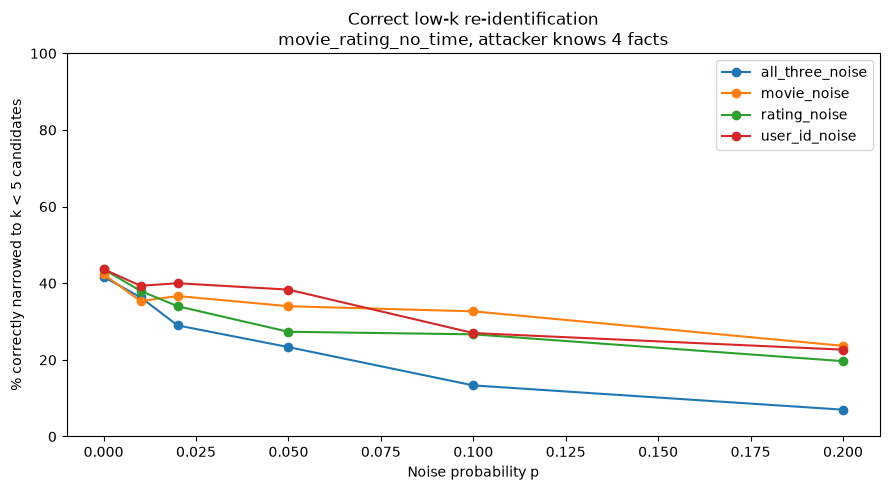

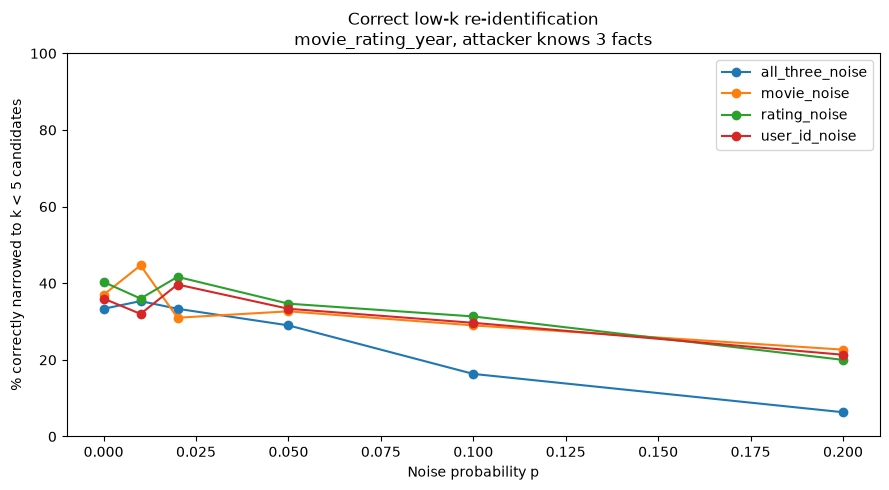

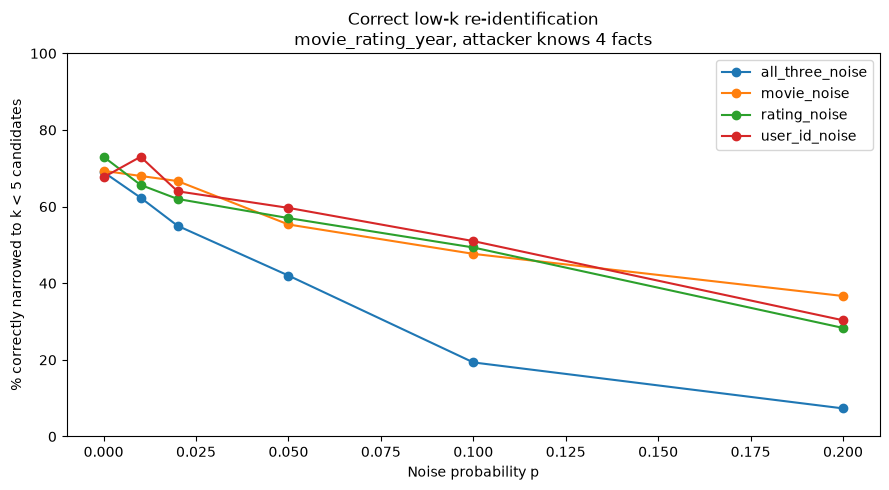

In [104]:
# Plot: percent of trials where the attack returns k < 5 candidates
# AND the true user is actually inside that small candidate set.

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["pct_less_than_5_correct"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("% correctly narrowed to k < 5 candidates")
        plt.title(f"Correct low-k re-identification\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

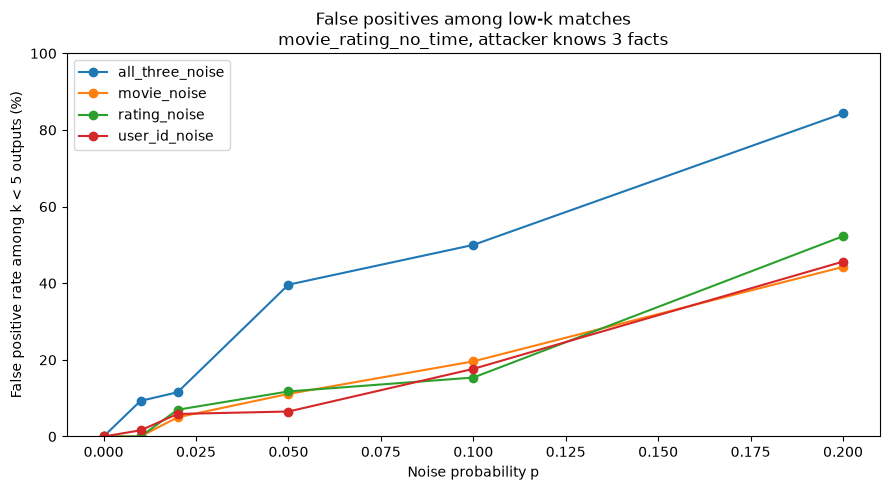

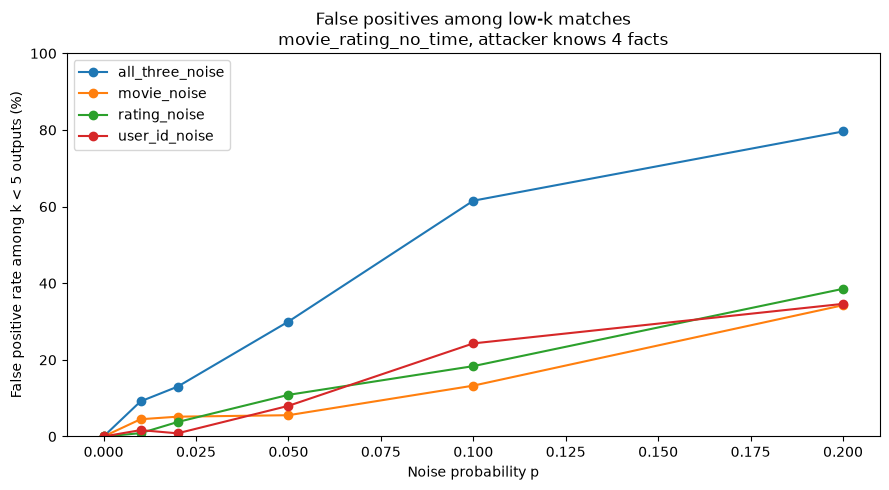

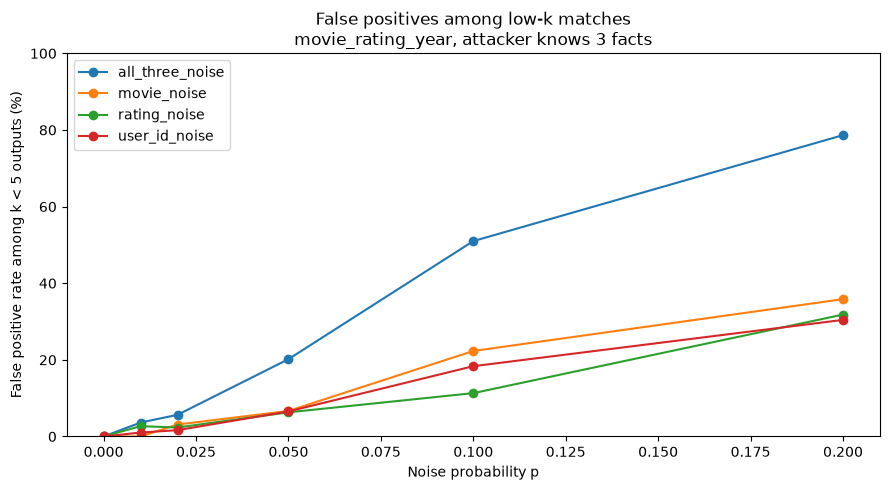

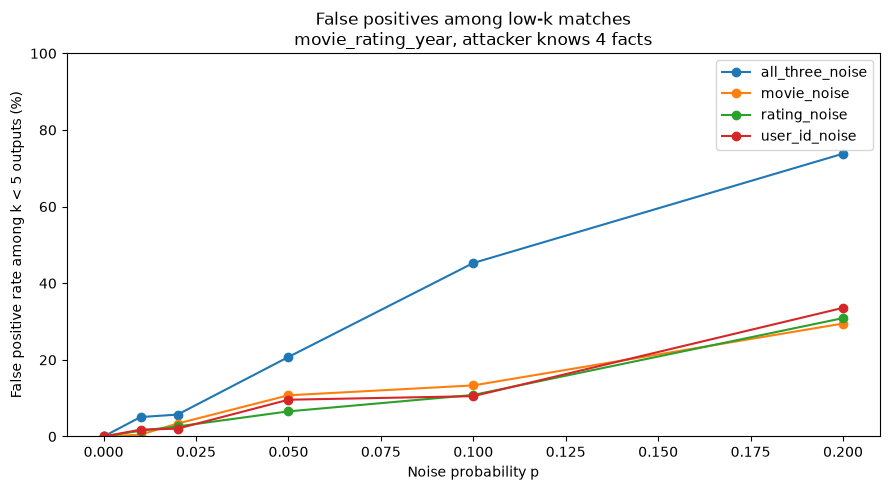

In [105]:
# Plot: among cases where the attack returns k < 5 candidates,
# how often is the true user NOT in that candidate set?

for knowledge_name in KNOWLEDGE_MODES_NO_MONTH.keys():
    for n_known in [3, 4]:
        chart_df = noise_summary[
            (noise_summary["knowledge_name"] == knowledge_name)
            & (noise_summary["n_known"] == n_known)
        ].copy()

        plt.figure(figsize=(9, 5))

        for scenario, part in chart_df.groupby("scenario"):
            part = part.sort_values("p")
            plt.plot(
                part["p"],
                part["false_positive_rate_among_less_than_5"],
                marker="o",
                label=scenario
            )

        plt.xlabel("Noise probability p")
        plt.ylabel("False positive rate among k < 5 outputs (%)")
        plt.title(f"False positives among low-k matches\n{knowledge_name}, attacker knows {n_known} facts")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [106]:
all_noise_results.to_csv("noise_attack_raw_results.csv", index=False)
noise_summary.to_csv("noise_attack_summary.csv", index=False)
main_noise_table.to_csv("noise_attack_main_table.csv", index=False)

print("Saved:")
print("noise_attack_raw_results.csv")
print("noise_attack_summary.csv")
print("noise_attack_main_table.csv")

Saved:
noise_attack_raw_results.csv
noise_attack_summary.csv
noise_attack_main_table.csv


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



UTILITY_SEED = 333
UTILITY_TEST_FRACTION = 0.20


UTILITY_SAMPLE_ROWS = None

BIAS_EPOCHS = 6
BIAS_REG = 10.0


def train_test_split_for_utility(frame, test_fraction=0.2, seed=333, sample_rows=None):
    data = frame[["user_id", "movie_id", "rating"]].dropna().copy()

    if sample_rows is not None and len(data) > sample_rows:
        data = data.sample(sample_rows, random_state=seed).copy()

    rng = np.random.default_rng(seed)
    is_test = rng.random(len(data)) < test_fraction

    train = data.loc[~is_test].reset_index(drop=True)
    test = data.loc[is_test].reset_index(drop=True)

    return train, test


def fit_bias_recommender(train, epochs=6, reg=10.0):
    """
    Fast recommender baseline:
        prediction = global_mean + user_bias + movie_bias

    This is much cheaper than fitting ALS for every noise setting.
    """
    train = train[["user_id", "movie_id", "rating"]].dropna().copy()

    user_codes, user_index = pd.factorize(train["user_id"], sort=False)
    movie_codes, movie_index = pd.factorize(train["movie_id"], sort=False)

    y = train["rating"].astype(float).to_numpy()
    global_mean = float(y.mean())

    user_bias = np.zeros(len(user_index), dtype=float)
    movie_bias = np.zeros(len(movie_index), dtype=float)

    user_counts = np.bincount(user_codes, minlength=len(user_index)).astype(float)
    movie_counts = np.bincount(movie_codes, minlength=len(movie_index)).astype(float)

    for _ in range(epochs):
        residual_for_users = y - global_mean - movie_bias[movie_codes]
        user_sums = np.bincount(user_codes, weights=residual_for_users, minlength=len(user_index))
        user_bias = user_sums / (user_counts + reg)

        residual_for_movies = y - global_mean - user_bias[user_codes]
        movie_sums = np.bincount(movie_codes, weights=residual_for_movies, minlength=len(movie_index))
        movie_bias = movie_sums / (movie_counts + reg)

    return {
        "global_mean": global_mean,
        "user_bias": pd.Series(user_bias, index=user_index),
        "movie_bias": pd.Series(movie_bias, index=movie_index),
    }


def predict_bias_recommender(model, test):
    pred = (
        model["global_mean"]
        + test["user_id"].map(model["user_bias"]).fillna(0).to_numpy()
        + test["movie_id"].map(model["movie_bias"]).fillna(0).to_numpy()
    )
    return np.clip(pred, 1, 5)


def recommender_metrics(y_true, y_pred):
    err = y_pred - y_true
    return {
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(np.abs(err))),
        "within_1_star_pct": float(np.mean(np.abs(err) <= 1.0) * 100),
    }


utility_train_clean, utility_test_clean = train_test_split_for_utility(
    df_attack,
    test_fraction=UTILITY_TEST_FRACTION,
    seed=UTILITY_SEED,
    sample_rows=UTILITY_SAMPLE_ROWS,
)

y_test = utility_test_clean["rating"].astype(float).to_numpy()

# Dumb baseline: always predict clean training mean.
global_pred = np.full(len(utility_test_clean), utility_train_clean["rating"].mean())
global_metrics = recommender_metrics(y_test, global_pred)
global_rmse = global_metrics["rmse"]

# Clean recommender baseline.
clean_model = fit_bias_recommender(
    utility_train_clean,
    epochs=BIAS_EPOCHS,
    reg=BIAS_REG,
)

clean_pred = predict_bias_recommender(clean_model, utility_test_clean)
clean_metrics = recommender_metrics(y_test, clean_pred)
clean_rmse = clean_metrics["rmse"]

print("Utility train rows:", len(utility_train_clean))
print("Utility test rows:", len(utility_test_clean))
print("Global mean baseline RMSE:", round(global_rmse, 4))
print("Clean recommender RMSE:", round(clean_rmse, 4))
print("Clean recommender within-1-star %:", round(clean_metrics["within_1_star_pct"], 2))

Utility train rows: 19241950
Utility test rows: 4811814
Global mean baseline RMSE: 1.0864
Clean recommender RMSE: 0.9319
Clean recommender within-1-star %: 73.1


In [108]:

utility_rows = []
utility_base_seed = 70000
utility_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        # Noise is applied only to the released training data.
        # The test set remains the true held-out ratings.
        noisy_train = make_noisy_release(
            utility_train_clean,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=utility_base_seed + utility_counter,
            weighted_sampling= weighted_samplings
        )

        model = fit_bias_recommender(
            noisy_train,
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

        pred = predict_bias_recommender(model, utility_test_clean)
        metrics = recommender_metrics(y_test, pred)

        utility_rows.append({
            "scenario": scenario,
            "p": p,
            "model": "bias_recommender",
            "rating_p": rating_p,
            "movie_p": movie_p,
            "user_p": user_p,
            **metrics,
        })

        utility_counter += 1

utility_summary = pd.DataFrame(utility_rows)

# RMSE-based utility retained:
# 100% = clean recommender
# 0% = global-mean-only recommender
if global_rmse > clean_rmse:
    utility_summary["rmse_utility_retained_pct"] = (
        100 * (global_rmse - utility_summary["rmse"]) / (global_rmse - clean_rmse)
    )
else:
    utility_summary["rmse_utility_retained_pct"] = np.nan

# Accuracy-style utility retained:
# 100% = same within-1-star accuracy as clean recommender.
utility_summary["within_1_star_retained_pct"] = (
    100 * utility_summary["within_1_star_pct"] / clean_metrics["within_1_star_pct"]
)

utility_summary["rmse_increase_vs_clean_pct"] = (
    100 * (utility_summary["rmse"] - clean_rmse) / clean_rmse
)

display(
    utility_summary.sort_values(["scenario", "p"])[[
        "scenario",
        "p",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
        "rmse_increase_vs_clean_pct",
    ]]
)

utility_summary.to_csv("downstream_recommender_utility_summary.csv", index=False)
print("Saved downstream_recommender_utility_summary.csv")

Utility eval: rating_noise p = 0.0
Utility eval: rating_noise p = 0.01
Utility eval: rating_noise p = 0.02
Utility eval: rating_noise p = 0.05
Utility eval: rating_noise p = 0.1
Utility eval: rating_noise p = 0.2
Utility eval: movie_noise p = 0.0
Utility eval: movie_noise p = 0.01
Utility eval: movie_noise p = 0.02
Utility eval: movie_noise p = 0.05
Utility eval: movie_noise p = 0.1
Utility eval: movie_noise p = 0.2
Utility eval: user_id_noise p = 0.0
Utility eval: user_id_noise p = 0.01
Utility eval: user_id_noise p = 0.02
Utility eval: user_id_noise p = 0.05
Utility eval: user_id_noise p = 0.1
Utility eval: user_id_noise p = 0.2
Utility eval: all_three_noise p = 0.0
Utility eval: all_three_noise p = 0.01
Utility eval: all_three_noise p = 0.02
Utility eval: all_three_noise p = 0.05
Utility eval: all_three_noise p = 0.1
Utility eval: all_three_noise p = 0.2


,scenario,p,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct
18,all_three_noise,0.00,0.931949,0.733283,73.100706,100.000000,100.000000,0.000000
19,all_three_noise,0.01,0.933097,0.735475,72.894464,99.717865,99.256384,0.123207
20,all_three_noise,0.02,0.934436,0.737781,72.678183,99.421999,98.389458,0.266844
21,all_three_noise,0.05,0.938943,0.745068,72.012301,98.511089,95.470752,0.750433
22,all_three_noise,0.10,0.948411,0.758767,70.675342,96.682161,89.338839,1.766405
23,all_three_noise,0.20,0.974470,0.791357,67.592077,92.464328,72.462370,4.562599
6,movie_noise,0.00,0.931949,0.733283,73.100706,100.000000,100.000000,0.000000
7,movie_noise,0.01,0.932324,0.733680,73.075123,99.965003,99.757140,0.040239
8,movie_noise,0.02,0.932772,0.734105,73.041581,99.919118,99.467190,0.088279
9,movie_noise,0.05,0.933976,0.735219,72.977135,99.830958,98.687622,0.217443


Saved downstream_recommender_utility_summary.csv


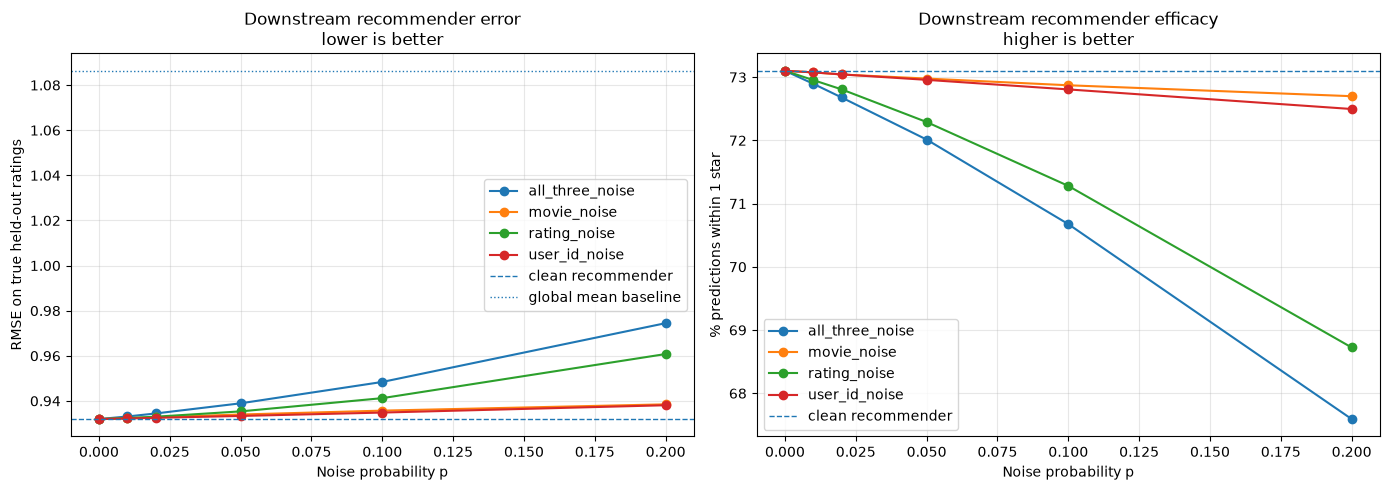

In [109]:
# -------------------------------------
# Plot downstream recommendation utility
# -------------------------------------

plot_utility = utility_summary.sort_values(["scenario", "p"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for scenario, part in plot_utility.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["rmse"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["within_1_star_pct"],
        marker="o",
        label=scenario,
    )

axes[0].axhline(clean_rmse, linestyle="--", linewidth=1, label="clean recommender")
axes[0].axhline(global_rmse, linestyle=":", linewidth=1, label="global mean baseline")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylabel("RMSE on true held-out ratings")
axes[0].set_title("Downstream recommender error\nlower is better")

axes[1].axhline(clean_metrics["within_1_star_pct"], linestyle="--", linewidth=1, label="clean recommender")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylabel("% predictions within 1 star")
axes[1].set_title("Downstream recommender efficacy\nhigher is better")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

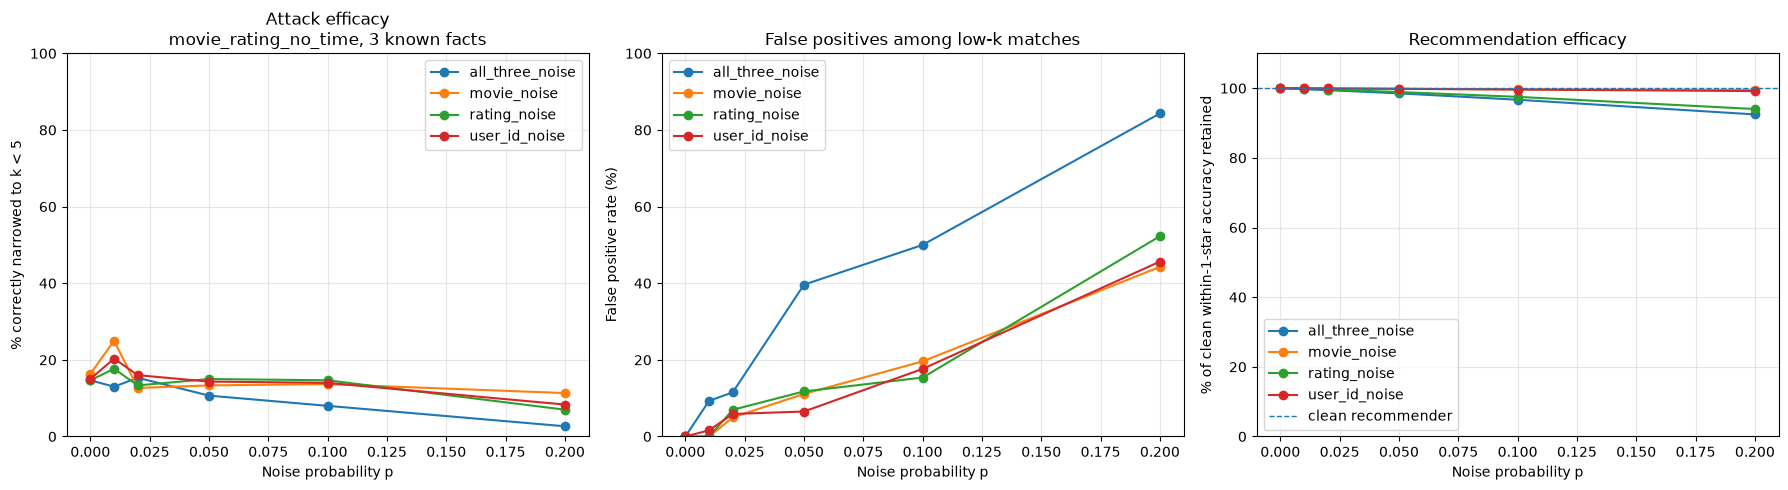

,scenario,p,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct
0,all_three_noise,0.00,14.666667,0.000000,0.931949,0.733283,73.100706,100.000000
1,all_three_noise,0.01,13.000000,9.302326,0.933097,0.735475,72.894464,99.717865
2,all_three_noise,0.02,15.333333,11.538462,0.934436,0.737781,72.678183,99.421999
3,all_three_noise,0.05,10.666667,39.622642,0.938943,0.745068,72.012301,98.511089
4,all_three_noise,0.10,8.000000,50.000000,0.948411,0.758767,70.675342,96.682161
5,all_three_noise,0.20,2.666667,84.313725,0.974470,0.791357,67.592077,92.464328
6,movie_noise,0.00,16.333333,0.000000,0.931949,0.733283,73.100706,100.000000
7,movie_noise,0.01,25.000000,0.000000,0.932324,0.733680,73.075123,99.965003
8,movie_noise,0.02,12.666667,5.000000,0.932772,0.734105,73.041581,99.919118
9,movie_noise,0.05,13.333333,11.111111,0.933976,0.735219,72.977135,99.830958


Saved combined_privacy_utility_summary.csv


In [110]:


PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_plot = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

combined_summary = privacy_for_plot.merge(
    utility_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for scenario, part in combined_summary.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["false_positive_rate_among_less_than_5"],
        marker="o",
        label=scenario,
    )

    axes[2].plot(
        part["p"],
        part["within_1_star_retained_pct"],
        marker="o",
        label=scenario,
    )

axes[0].set_title(f"Attack efficacy\n{PLOT_KNOWLEDGE_NAME}, {PLOT_N_KNOWN} known facts")
axes[0].set_ylabel("% correctly narrowed to k < 5")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylim(0, 100)

axes[1].set_title("False positives among low-k matches")
axes[1].set_ylabel("False positive rate (%)")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylim(0, 100)

axes[2].axhline(100, linestyle="--", linewidth=1, label="clean recommender")
axes[2].set_title("Recommendation efficacy")
axes[2].set_ylabel("% of clean within-1-star accuracy retained")
axes[2].set_xlabel("Noise probability p")
axes[2].set_ylim(0, max(110, combined_summary["within_1_star_retained_pct"].max() * 1.05))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(combined_summary[[
    "scenario",
    "p",
    "pct_less_than_5_correct",
    "false_positive_rate_among_less_than_5",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
]].sort_values(["scenario", "p"]))

combined_summary.to_csv("combined_privacy_utility_summary.csv", index=False)
print("Saved combined_privacy_utility_summary.csv")

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UTILITY_SEED = 333
UTILITY_TEST_FRACTION = 0.20
UTILITY_SAMPLE_ROWS = None
BIAS_EPOCHS = 6
BIAS_REG = 10.0


class BiasRecommender:
    def __init__(self, global_mean, user_bias, item_bias, user_col, item_col):
        self.global_mean = global_mean
        self.user_bias = user_bias
        self.item_bias = item_bias
        self.user_col = user_col
        self.item_col = item_col

    def predict(self, frame):
        pred = (
            self.global_mean
            + frame[self.user_col].map(self.user_bias).fillna(0).to_numpy()
            + frame[self.item_col].map(self.item_bias).fillna(0).to_numpy()
        )
        return np.clip(pred, 1, 5)


def train_test_split_ratings(frame, test_fraction=0.2, seed=333, sample_rows=None):
    data = frame[["user_id", "movie_id", "rating"]].dropna().copy()
    data["rating"] = data["rating"].astype(float)

    if sample_rows is not None and len(data) > sample_rows:
        data = data.sample(sample_rows, random_state=seed).copy()

    rng = np.random.default_rng(seed)
    is_test = rng.random(len(data)) < test_fraction

    train = data.loc[~is_test].reset_index(drop=True)
    test = data.loc[is_test].reset_index(drop=True)

    return train, test


def fit_bias_recommender(frame, user_col="user_id", item_col="movie_id", rating_col="rating", epochs=6, reg=10.0):
    train = frame[[user_col, item_col, rating_col]].dropna().copy()
    train[rating_col] = train[rating_col].astype(float)

    user_codes, user_index = pd.factorize(train[user_col], sort=False)
    item_codes, item_index = pd.factorize(train[item_col], sort=False)

    y = train[rating_col].to_numpy(dtype=float)
    global_mean = float(y.mean())

    user_bias = np.zeros(len(user_index), dtype=float)
    item_bias = np.zeros(len(item_index), dtype=float)

    user_counts = np.bincount(user_codes, minlength=len(user_index)).astype(float)
    item_counts = np.bincount(item_codes, minlength=len(item_index)).astype(float)

    for _ in range(epochs):
        user_resid = y - global_mean - item_bias[item_codes]
        user_sums = np.bincount(user_codes, weights=user_resid, minlength=len(user_index))
        user_bias = user_sums / (user_counts + reg)

        item_resid = y - global_mean - user_bias[user_codes]
        item_sums = np.bincount(item_codes, weights=item_resid, minlength=len(item_index))
        item_bias = item_sums / (item_counts + reg)

    return BiasRecommender(
        global_mean=global_mean,
        user_bias=pd.Series(user_bias, index=user_index),
        item_bias=pd.Series(item_bias, index=item_index),
        user_col=user_col,
        item_col=item_col,
    )


def rmse(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((actual - pred) ** 2)))


def mae(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred)))


def within_one_star(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(actual - pred) <= 1.0) * 100)


utility_train_clean, utility_test_clean = train_test_split_ratings(
    df_attack,
    test_fraction=UTILITY_TEST_FRACTION,
    seed=UTILITY_SEED,
    sample_rows=UTILITY_SAMPLE_ROWS,
)

actual = utility_test_clean["rating"].to_numpy(dtype=float)

global_pred = np.full(len(utility_test_clean), utility_train_clean["rating"].mean())
global_rmse = rmse(actual, global_pred)
global_mae = mae(actual, global_pred)
global_within_1 = within_one_star(actual, global_pred)

clean_model = fit_bias_recommender(
    utility_train_clean,
    user_col="user_id",
    item_col="movie_id",
    rating_col="rating",
    epochs=BIAS_EPOCHS,
    reg=BIAS_REG,
)

clean_pred = clean_model.predict(utility_test_clean)
clean_rmse = rmse(actual, clean_pred)
clean_mae = mae(actual, clean_pred)
clean_within_1 = within_one_star(actual, clean_pred)

print("train rows:", len(utility_train_clean))
print("test rows:", len(utility_test_clean))
print("global rmse:", round(global_rmse, 4))
print("clean bias rmse:", round(clean_rmse, 4))
print("clean bias mae:", round(clean_mae, 4))
print("clean bias within 1 star:", round(clean_within_1, 2))

train rows: 19241950
test rows: 4811814
global rmse: 1.0864
clean bias rmse: 0.9319
clean bias mae: 0.7333
clean bias within 1 star: 73.1


In [112]:
utility_rows = []
utility_base_seed = 70000
utility_counter = 0

for scenario in noise_scenarios:
    for p in p_values:
        print("Utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0

        noisy_train = make_noisy_release(
            utility_train_clean,
            rating_p=rating_p,
            movie_p=movie_p,
            user_p=user_p,
            seed=utility_base_seed + utility_counter,
            weighted_sampling = weighted_samplings
        )

        model = fit_bias_recommender(
            noisy_train,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

        pred = model.predict(utility_test_clean)

        utility_rows.append({
            "scenario": scenario,
            "p": p,
            "model": "bias",
            "rating_p": rating_p,
            "movie_p": movie_p,
            "user_p": user_p,
            "rmse": rmse(actual, pred),
            "mae": mae(actual, pred),
            "within_1_star_pct": within_one_star(actual, pred),
        })

        utility_counter += 1

utility_summary = pd.DataFrame(utility_rows)

utility_summary["rmse_increase_vs_clean_pct"] = (
    100 * (utility_summary["rmse"] - clean_rmse) / clean_rmse
)

utility_summary["mae_increase_vs_clean_pct"] = (
    100 * (utility_summary["mae"] - clean_mae) / clean_mae
)

utility_summary["within_1_star_retained_pct"] = (
    100 * utility_summary["within_1_star_pct"] / clean_within_1
)

if global_rmse > clean_rmse:
    utility_summary["rmse_utility_retained_pct"] = (
        100 * (global_rmse - utility_summary["rmse"]) / (global_rmse - clean_rmse)
    )
else:
    utility_summary["rmse_utility_retained_pct"] = np.nan

display(
    utility_summary.sort_values(["scenario", "p"])[[
        "scenario",
        "p",
        "model",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
        "rmse_increase_vs_clean_pct",
        "mae_increase_vs_clean_pct",
    ]]
)

utility_summary.to_csv("downstream_bias_recommender_utility_summary.csv", index=False)
print("Saved downstream_bias_recommender_utility_summary.csv")

Utility eval: rating_noise p = 0.0
Utility eval: rating_noise p = 0.01
Utility eval: rating_noise p = 0.02
Utility eval: rating_noise p = 0.05
Utility eval: rating_noise p = 0.1
Utility eval: rating_noise p = 0.2
Utility eval: movie_noise p = 0.0
Utility eval: movie_noise p = 0.01
Utility eval: movie_noise p = 0.02
Utility eval: movie_noise p = 0.05
Utility eval: movie_noise p = 0.1
Utility eval: movie_noise p = 0.2
Utility eval: user_id_noise p = 0.0
Utility eval: user_id_noise p = 0.01
Utility eval: user_id_noise p = 0.02
Utility eval: user_id_noise p = 0.05
Utility eval: user_id_noise p = 0.1
Utility eval: user_id_noise p = 0.2
Utility eval: all_three_noise p = 0.0
Utility eval: all_three_noise p = 0.01
Utility eval: all_three_noise p = 0.02
Utility eval: all_three_noise p = 0.05
Utility eval: all_three_noise p = 0.1
Utility eval: all_three_noise p = 0.2


,scenario,p,model,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct,mae_increase_vs_clean_pct
18,all_three_noise,0.00,bias,0.931949,0.733283,73.100706,100.000000,100.000000,0.000000,0.000000
19,all_three_noise,0.01,bias,0.933097,0.735475,72.894464,99.717865,99.256384,0.123207,0.298932
20,all_three_noise,0.02,bias,0.934436,0.737781,72.678183,99.421999,98.389458,0.266844,0.613494
21,all_three_noise,0.05,bias,0.938943,0.745068,72.012301,98.511089,95.470752,0.750433,1.607284
22,all_three_noise,0.10,bias,0.948411,0.758767,70.675342,96.682161,89.338839,1.766405,3.475365
23,all_three_noise,0.20,bias,0.974470,0.791357,67.592077,92.464328,72.462370,4.562599,7.919813
6,movie_noise,0.00,bias,0.931949,0.733283,73.100706,100.000000,100.000000,0.000000,0.000000
7,movie_noise,0.01,bias,0.932324,0.733680,73.075123,99.965003,99.757140,0.040239,0.054222
8,movie_noise,0.02,bias,0.932772,0.734105,73.041581,99.919118,99.467190,0.088279,0.112176
9,movie_noise,0.05,bias,0.933976,0.735219,72.977135,99.830958,98.687622,0.217443,0.264015


Saved downstream_bias_recommender_utility_summary.csv


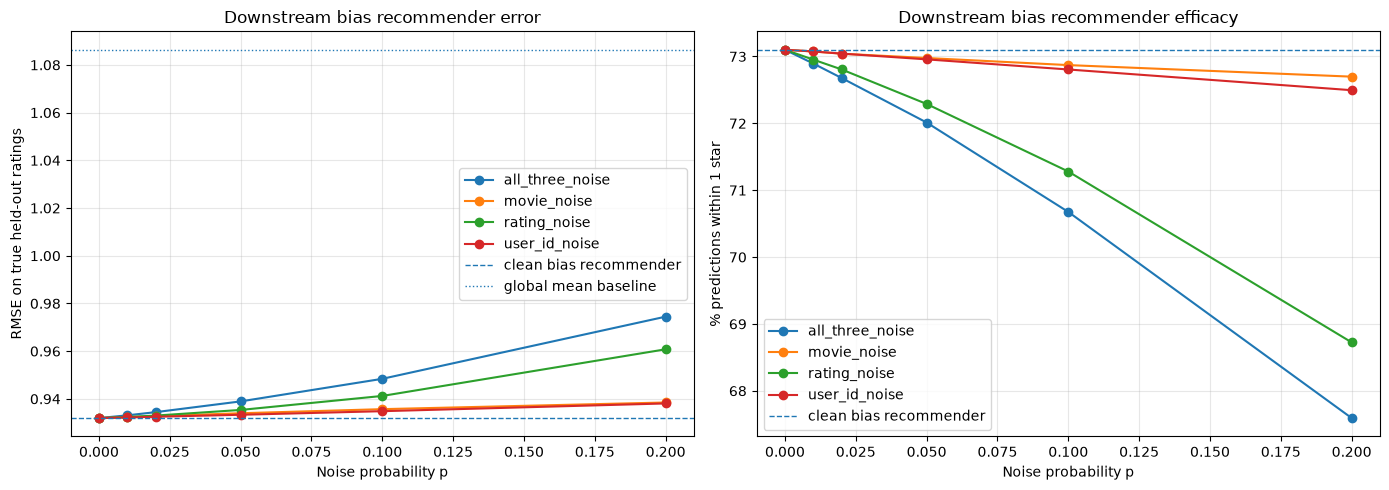

In [113]:
plot_utility = utility_summary.sort_values(["scenario", "p"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for scenario, part in plot_utility.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["rmse"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["within_1_star_pct"],
        marker="o",
        label=scenario,
    )

axes[0].axhline(clean_rmse, linestyle="--", linewidth=1, label="clean bias recommender")
axes[0].axhline(global_rmse, linestyle=":", linewidth=1, label="global mean baseline")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylabel("RMSE on true held-out ratings")
axes[0].set_title("Downstream bias recommender error")

axes[1].axhline(clean_within_1, linestyle="--", linewidth=1, label="clean bias recommender")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylabel("% predictions within 1 star")
axes[1].set_title("Downstream bias recommender efficacy")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

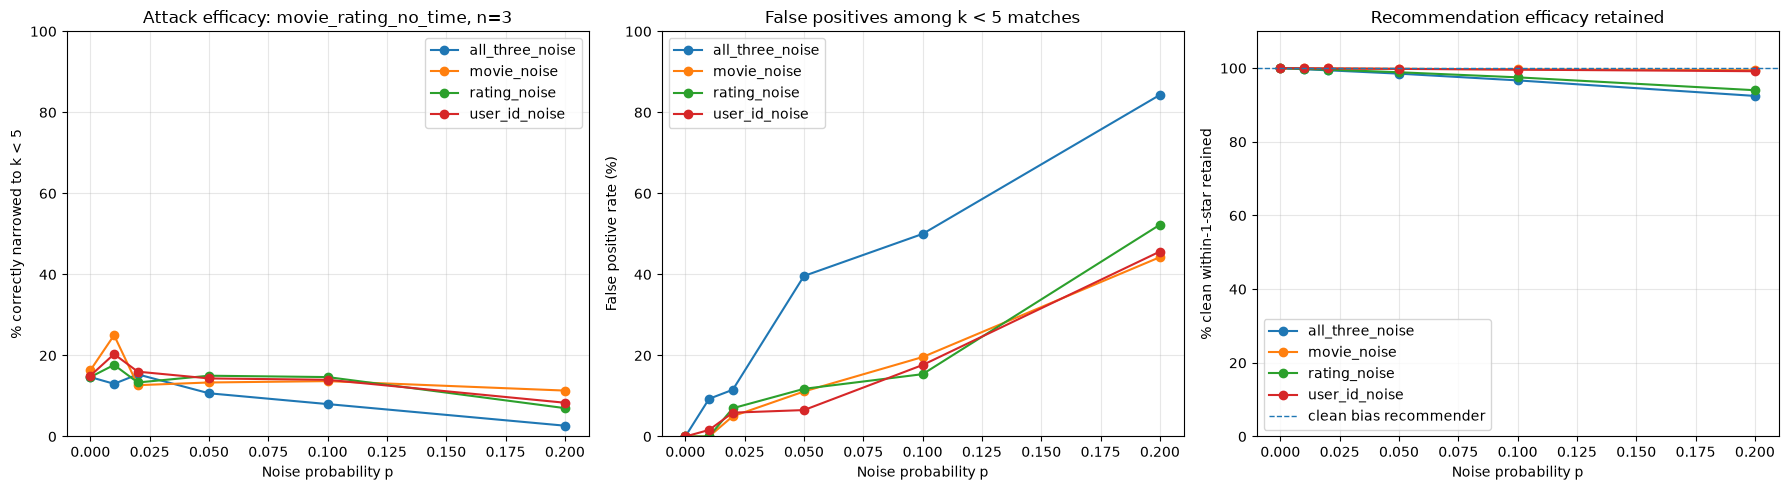

,scenario,p,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct
0,all_three_noise,0.00,14.666667,0.000000,0.931949,0.733283,73.100706,100.000000,100.000000
1,all_three_noise,0.01,13.000000,9.302326,0.933097,0.735475,72.894464,99.717865,99.256384
2,all_three_noise,0.02,15.333333,11.538462,0.934436,0.737781,72.678183,99.421999,98.389458
3,all_three_noise,0.05,10.666667,39.622642,0.938943,0.745068,72.012301,98.511089,95.470752
4,all_three_noise,0.10,8.000000,50.000000,0.948411,0.758767,70.675342,96.682161,89.338839
5,all_three_noise,0.20,2.666667,84.313725,0.974470,0.791357,67.592077,92.464328,72.462370
6,movie_noise,0.00,16.333333,0.000000,0.931949,0.733283,73.100706,100.000000,100.000000
7,movie_noise,0.01,25.000000,0.000000,0.932324,0.733680,73.075123,99.965003,99.757140
8,movie_noise,0.02,12.666667,5.000000,0.932772,0.734105,73.041581,99.919118,99.467190
9,movie_noise,0.05,13.333333,11.111111,0.933976,0.735219,72.977135,99.830958,98.687622


Saved combined_privacy_bias_utility_summary.csv


In [114]:
PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_plot = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

combined_summary = privacy_for_plot.merge(
    utility_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for scenario, part in combined_summary.groupby("scenario"):
    part = part.sort_values("p")

    axes[0].plot(
        part["p"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    axes[1].plot(
        part["p"],
        part["false_positive_rate_among_less_than_5"],
        marker="o",
        label=scenario,
    )

    axes[2].plot(
        part["p"],
        part["within_1_star_retained_pct"],
        marker="o",
        label=scenario,
    )

axes[0].set_title(f"Attack efficacy: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}")
axes[0].set_ylabel("% correctly narrowed to k < 5")
axes[0].set_xlabel("Noise probability p")
axes[0].set_ylim(0, 100)

axes[1].set_title("False positives among k < 5 matches")
axes[1].set_ylabel("False positive rate (%)")
axes[1].set_xlabel("Noise probability p")
axes[1].set_ylim(0, 100)

axes[2].axhline(100, linestyle="--", linewidth=1, label="clean bias recommender")
axes[2].set_title("Recommendation efficacy retained")
axes[2].set_ylabel("% clean within-1-star retained")
axes[2].set_xlabel("Noise probability p")
axes[2].set_ylim(0, max(110, combined_summary["within_1_star_retained_pct"].max() * 1.05))

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

display(combined_summary[[
    "scenario",
    "p",
    "pct_less_than_5_correct",
    "false_positive_rate_among_less_than_5",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
    "rmse_utility_retained_pct",
]].sort_values(["scenario", "p"]))

combined_summary.to_csv("combined_privacy_bias_utility_summary.csv", index=False)
print("Saved combined_privacy_bias_utility_summary.csv")

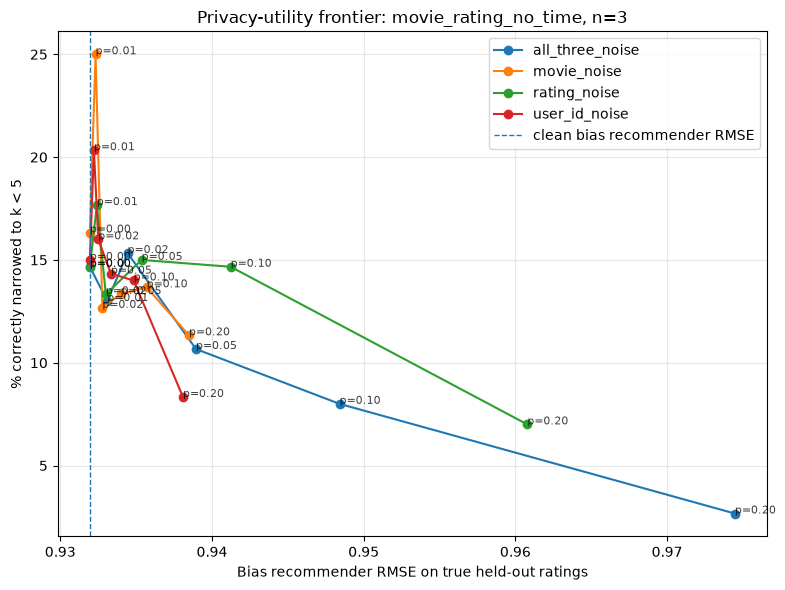

In [115]:
frontier_df = combined_summary.dropna(subset=["rmse", "pct_less_than_5_correct"]).copy()

plt.figure(figsize=(8, 6))

for scenario, part in frontier_df.groupby("scenario"):
    part = part.sort_values("p")

    plt.plot(
        part["rmse"],
        part["pct_less_than_5_correct"],
        marker="o",
        label=scenario,
    )

    for _, row in part.iterrows():
        plt.annotate(
            f"p={row['p']:.2f}",
            (row["rmse"], row["pct_less_than_5_correct"]),
            fontsize=8,
            alpha=0.75,
        )

plt.axvline(clean_rmse, linestyle="--", linewidth=1, label="clean bias recommender RMSE")
plt.xlabel("Bias recommender RMSE on true held-out ratings")
plt.ylabel("% correctly narrowed to k < 5")
plt.title(f"Privacy-utility frontier: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
!pip -q install pyspark

import gc
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS

KNN_K = 30
KNN_MIN_SIMILARITY = 0.05
ALS_RANK = 40
ALS_MAX_ITER = 10
ALS_REG = 0.1

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("NetflixNoiseUtility")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.driver.memory", "14g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

In [117]:
class ItemKNNRecommender:
    def __init__(self, baseline, item_to_code, similarity_matrix, user_history):
        self.baseline = baseline
        self.item_to_code = item_to_code
        self.similarity_matrix = similarity_matrix
        self.user_history = user_history

    def predict(self, frame):
        pred = self.baseline.predict(frame).astype(float)
        users = frame["user_id"].to_numpy()
        items = frame["movie_id"].to_numpy()

        for row_idx, (user_id, item_id) in enumerate(zip(users, items)):
            target_code = self.item_to_code.get(item_id)
            history = self.user_history.get(user_id)

            if target_code is None or history is None:
                continue

            history_codes, history_residuals = history
            weights = self.similarity_matrix[target_code, history_codes]
            valid = weights > 0

            if valid.any():
                pred[row_idx] += float(
                    np.dot(weights[valid], history_residuals[valid])
                    / np.abs(weights[valid]).sum()
                )

        return np.clip(pred, 1, 5)


def fit_item_knn_recommender(
    train,
    baseline_model=None,
    k=30,
    min_similarity=0.05,
):
    work = train[["user_id", "movie_id", "rating"]].dropna().copy()
    work = work.groupby(["user_id", "movie_id"], as_index=False)["rating"].mean()

    baseline = baseline_model

    if baseline is None:
        baseline = fit_bias_recommender(
            work,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

    residuals = work["rating"].to_numpy(dtype=float) - baseline.predict(work)

    user_codes, user_ids = pd.factorize(work["user_id"], sort=False)
    item_codes, item_ids = pd.factorize(work["movie_id"], sort=False)

    item_user_residuals = csr_matrix(
        (residuals, (item_codes, user_codes)),
        shape=(len(item_ids), len(user_ids)),
    )

    n_neighbors = min(k + 1, len(item_ids))

    neighbor_model = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute",
        n_jobs=-1,
    )

    neighbor_model.fit(item_user_residuals)

    distances, neighbor_codes = neighbor_model.kneighbors(
        item_user_residuals,
        return_distance=True,
    )

    similarity_matrix = np.zeros(
        (len(item_ids), len(item_ids)),
        dtype=np.float32,
    )

    for item_code in range(len(item_ids)):
        codes = neighbor_codes[item_code]
        similarities = 1.0 - distances[item_code]
        keep = (codes != item_code) & (similarities >= min_similarity)
        similarity_matrix[item_code, codes[keep]] = similarities[keep].astype(
            np.float32
        )

    order = np.argsort(user_codes, kind="stable")
    counts = np.bincount(user_codes, minlength=len(user_ids))
    stops = np.cumsum(counts)
    starts = np.concatenate(([0], stops[:-1]))

    user_history = {}

    for user_code, user_id in enumerate(user_ids):
        positions = order[starts[user_code]:stops[user_code]]
        user_history[user_id] = (
            item_codes[positions],
            residuals[positions],
        )

    item_to_code = {
        item_id: item_code
        for item_code, item_id in enumerate(item_ids)
    }

    return ItemKNNRecommender(
        baseline=baseline,
        item_to_code=item_to_code,
        similarity_matrix=similarity_matrix,
        user_history=user_history,
    )

In [118]:
class SparkALSRecommender:
    def __init__(self, baseline, model):
        self.baseline = baseline
        self.model = model

    def predict(self, frame):
        base_pred = self.baseline.predict(frame).astype(float)

        prediction_input = pd.DataFrame({
            "_row_id": np.arange(len(frame), dtype=np.int64),
            "user_id": frame["user_id"].to_numpy(dtype=np.int32),
            "movie_id": frame["movie_id"].to_numpy(dtype=np.int32),
        })

        prediction_spark = spark.createDataFrame(prediction_input)

        prediction_output = (
            self.model
            .transform(prediction_spark)
            .select("_row_id", "prediction")
            .toPandas()
        )

        residual_pred = np.zeros(len(frame), dtype=float)

        if len(prediction_output) > 0:
            row_ids = prediction_output["_row_id"].to_numpy(dtype=int)
            values = prediction_output["prediction"].to_numpy(dtype=float)
            finite = np.isfinite(values)
            residual_pred[row_ids[finite]] = values[finite]

        return np.clip(base_pred + residual_pred, 1, 5)


def fit_als_recommender(
    train,
    baseline_model=None,
    rank=10,
    max_iter=5,
    reg_param=0.15,
    seed=333,
):
    work = train[["user_id", "movie_id", "rating"]].dropna().copy()
    work = work.groupby(["user_id", "movie_id"], as_index=False)["rating"].mean()

    baseline = baseline_model

    if baseline is None:
        baseline = fit_bias_recommender(
            work,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            epochs=BIAS_EPOCHS,
            reg=BIAS_REG,
        )

    work["residual"] = (
        work["rating"].to_numpy(dtype=float)
        - baseline.predict(work)
    )

    als_input = work[["user_id", "movie_id", "residual"]].copy()
    als_input["user_id"] = als_input["user_id"].astype(np.int32)
    als_input["movie_id"] = als_input["movie_id"].astype(np.int32)
    als_input["residual"] = als_input["residual"].astype(np.float32)

    als_spark = spark.createDataFrame(als_input)

    estimator = ALS(
        userCol="user_id",
        itemCol="movie_id",
        ratingCol="residual",
        rank=rank,
        maxIter=max_iter,
        regParam=reg_param,
        implicitPrefs=False,
        nonnegative=False,
        coldStartStrategy="drop",
        seed=seed,
        numUserBlocks=8,
        numItemBlocks=4,
        checkpointInterval=-1,
    )

    return SparkALSRecommender(
        baseline=baseline,
        model=estimator.fit(als_spark),
    )

In [119]:
clean_knn_model = fit_item_knn_recommender(
    utility_train_clean,
    baseline_model=clean_model,
    k=KNN_K,
    min_similarity=KNN_MIN_SIMILARITY,
)

clean_knn_pred = clean_knn_model.predict(utility_test_clean)

clean_als_model = fit_als_recommender(
    utility_train_clean,
    baseline_model=clean_model,
    rank=ALS_RANK,
    max_iter=ALS_MAX_ITER,
    reg_param=ALS_REG,
    seed=UTILITY_SEED,
)

clean_als_pred = clean_als_model.predict(utility_test_clean)

clean_model_comparison = pd.DataFrame([
    {
        "model": "Bias",
        "rmse": clean_rmse,
        "mae": clean_mae,
        "within_1_star_pct": clean_within_1,
    },
    {
        "model": "Item KNN",
        "rmse": rmse(actual, clean_knn_pred),
        "mae": mae(actual, clean_knn_pred),
        "within_1_star_pct": within_one_star(actual, clean_knn_pred),
    },
    {
        "model": "ALS",
        "rmse": rmse(actual, clean_als_pred),
        "mae": mae(actual, clean_als_pred),
        "within_1_star_pct": within_one_star(actual, clean_als_pred),
    },
])

display(clean_model_comparison)

,model,rmse,mae,within_1_star_pct
0,Bias,0.931949,0.733283,73.100706
1,Item KNN,0.958788,0.725401,74.156586
2,ALS,0.889912,0.692534,76.162420


In [120]:
advanced_rows = []
utility_base_seed = 70000
utility_counter = 0

clean_metric_lookup = clean_model_comparison.set_index("model").to_dict("index")

for scenario in noise_scenarios:
    for p in p_values:
        print("Advanced utility eval:", scenario, "p =", p)

        rating_p = p if scenario in ["rating_noise", "all_three_noise"] else 0.0
        movie_p = p if scenario in ["movie_noise", "all_three_noise"] else 0.0
        user_p = p if scenario in ["user_id_noise", "all_three_noise"] else 0.0
        release_seed = utility_base_seed + utility_counter

        if p == 0:
            for model_name in ["Item KNN", "ALS"]:
                advanced_rows.append({
                    "scenario": scenario,
                    "p": p,
                    "model": model_name,
                    "rating_p": rating_p,
                    "movie_p": movie_p,
                    "user_p": user_p,
                    **clean_metric_lookup[model_name],
                })
        else:
            noisy_train = make_noisy_release(
                utility_train_clean,
                rating_p=rating_p,
                movie_p=movie_p,
                user_p=user_p,
                seed=release_seed,
                weighted_sampling= weighted_samplings
            )

            noisy_bias_model = fit_bias_recommender(
                noisy_train,
                user_col="user_id",
                item_col="movie_id",
                rating_col="rating",
                epochs=BIAS_EPOCHS,
                reg=BIAS_REG,
            )

            knn_model = fit_item_knn_recommender(
                noisy_train,
                baseline_model=noisy_bias_model,
                k=KNN_K,
                min_similarity=KNN_MIN_SIMILARITY,
            )

            knn_pred = knn_model.predict(utility_test_clean)

            advanced_rows.append({
                "scenario": scenario,
                "p": p,
                "model": "Item KNN",
                "rating_p": rating_p,
                "movie_p": movie_p,
                "user_p": user_p,
                "rmse": rmse(actual, knn_pred),
                "mae": mae(actual, knn_pred),
                "within_1_star_pct": within_one_star(actual, knn_pred),
            })

            als_model = fit_als_recommender(
                noisy_train,
                baseline_model=noisy_bias_model,
                rank=ALS_RANK,
                max_iter=ALS_MAX_ITER,
                reg_param=ALS_REG,
                seed=release_seed,
            )

            als_pred = als_model.predict(utility_test_clean)

            advanced_rows.append({
                "scenario": scenario,
                "p": p,
                "model": "ALS",
                "rating_p": rating_p,
                "movie_p": movie_p,
                "user_p": user_p,
                "rmse": rmse(actual, als_pred),
                "mae": mae(actual, als_pred),
                "within_1_star_pct": within_one_star(actual, als_pred),
            })

            del noisy_train
            del noisy_bias_model
            del knn_model
            del knn_pred
            del als_model
            del als_pred

            spark.catalog.clearCache()
            gc.collect()

        utility_counter += 1

advanced_utility_summary = pd.DataFrame(advanced_rows)

bias_utility_summary = utility_summary.copy()
bias_utility_summary["model"] = "Bias"

all_model_summary = pd.concat(
    [bias_utility_summary, advanced_utility_summary],
    ignore_index=True,
    sort=False,
)

clean_rmse_lookup = clean_model_comparison.set_index("model")["rmse"]
clean_mae_lookup = clean_model_comparison.set_index("model")["mae"]
clean_within_lookup = clean_model_comparison.set_index("model")[
    "within_1_star_pct"
]

all_model_summary["clean_rmse"] = all_model_summary["model"].map(
    clean_rmse_lookup
)

all_model_summary["clean_mae"] = all_model_summary["model"].map(
    clean_mae_lookup
)

all_model_summary["clean_within_1_star_pct"] = all_model_summary["model"].map(
    clean_within_lookup
)

all_model_summary["rmse_increase_vs_clean_pct"] = (
    100
    * (all_model_summary["rmse"] - all_model_summary["clean_rmse"])
    / all_model_summary["clean_rmse"]
)

all_model_summary["mae_increase_vs_clean_pct"] = (
    100
    * (all_model_summary["mae"] - all_model_summary["clean_mae"])
    / all_model_summary["clean_mae"]
)

all_model_summary["within_1_star_retained_pct"] = (
    100
    * all_model_summary["within_1_star_pct"]
    / all_model_summary["clean_within_1_star_pct"]
)

rmse_denominator = global_rmse - all_model_summary["clean_rmse"]

all_model_summary["rmse_utility_retained_pct"] = np.where(
    rmse_denominator > 0,
    100
    * (global_rmse - all_model_summary["rmse"])
    / rmse_denominator,
    np.nan,
)

all_model_summary = all_model_summary.sort_values(
    ["scenario", "p", "model"]
).reset_index(drop=True)

display(all_model_summary[[
    "scenario",
    "p",
    "model",
    "rmse",
    "mae",
    "within_1_star_pct",
    "within_1_star_retained_pct",
    "rmse_utility_retained_pct",
    "rmse_increase_vs_clean_pct",
    "mae_increase_vs_clean_pct",
]])

clean_model_comparison.to_csv(
    "clean_recommender_model_comparison.csv",
    index=False,
)

all_model_summary.to_csv(
    "all_recommender_noise_utility_summary.csv",
    index=False,
)

print("Saved clean_recommender_model_comparison.csv")
print("Saved all_recommender_noise_utility_summary.csv")

Advanced utility eval: rating_noise p = 0.0
Advanced utility eval: rating_noise p = 0.01


Advanced utility eval: rating_noise p = 0.02


Advanced utility eval: rating_noise p = 0.05


Advanced utility eval: rating_noise p = 0.1


Advanced utility eval: rating_noise p = 0.2


...

Advanced utility eval: all_three_noise p = 0.05


Advanced utility eval: all_three_noise p = 0.1


Advanced utility eval: all_three_noise p = 0.2


,scenario,p,model,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct,rmse_increase_vs_clean_pct,mae_increase_vs_clean_pct
0,all_three_noise,0.00,ALS,0.889912,0.692534,76.162420,100.000000,100.000000,0.000000,0.000000
1,all_three_noise,0.00,Bias,0.931949,0.733283,73.100706,100.000000,100.000000,0.000000,0.000000
2,all_three_noise,0.00,Item KNN,0.958788,0.725401,74.156586,100.000000,100.000000,0.000000,0.000000
3,all_three_noise,0.01,ALS,0.892887,0.696286,75.879741,99.628847,98.485242,0.334383,0.541880
4,all_three_noise,0.01,Bias,0.933097,0.735475,72.894464,99.717865,99.256384,0.123207,0.298932
...,...,...,...,...,...,...,...,...,...,...
67,user_id_noise,0.10,Bias,0.934838,0.736972,72.805640,99.596358,98.129385,0.309935,0.503164
68,user_id_noise,0.10,Item KNN,0.964492,0.734721,73.345478,98.906223,95.528336,0.594980,1.284832
69,user_id_noise,0.20,ALS,0.904622,0.707133,75.158350,98.681672,92.512093,1.652957,2.108158
70,user_id_noise,0.20,Bias,0.938086,0.740908,72.495820,99.172530,96.025341,0.658545,1.039875


Saved clean_recommender_model_comparison.csv
Saved all_recommender_noise_utility_summary.csv


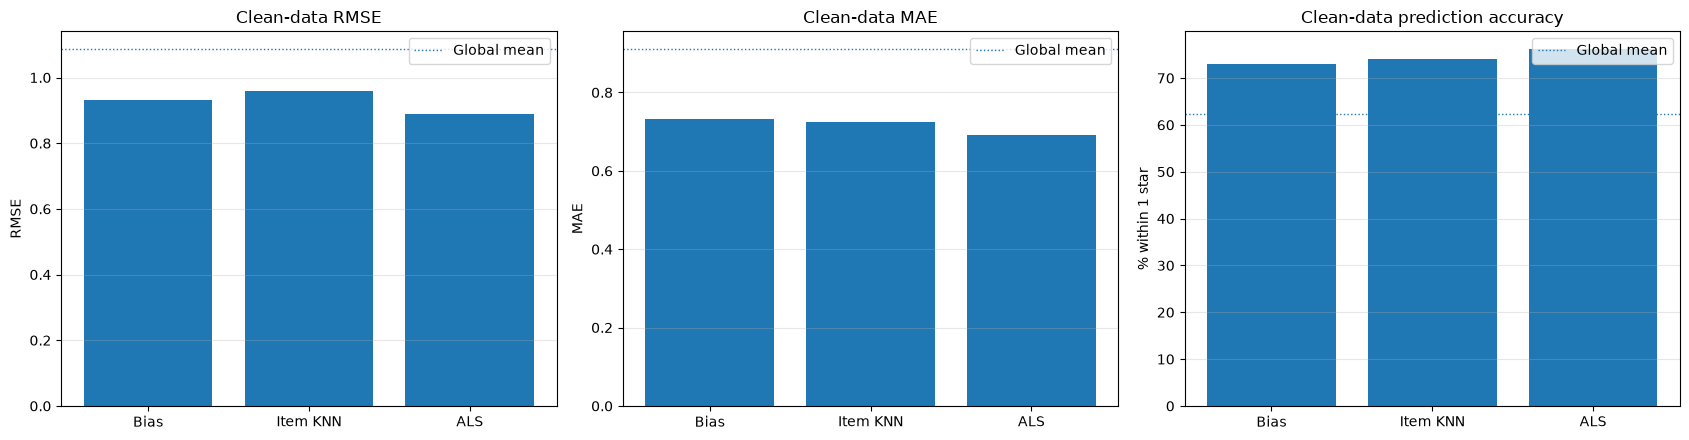

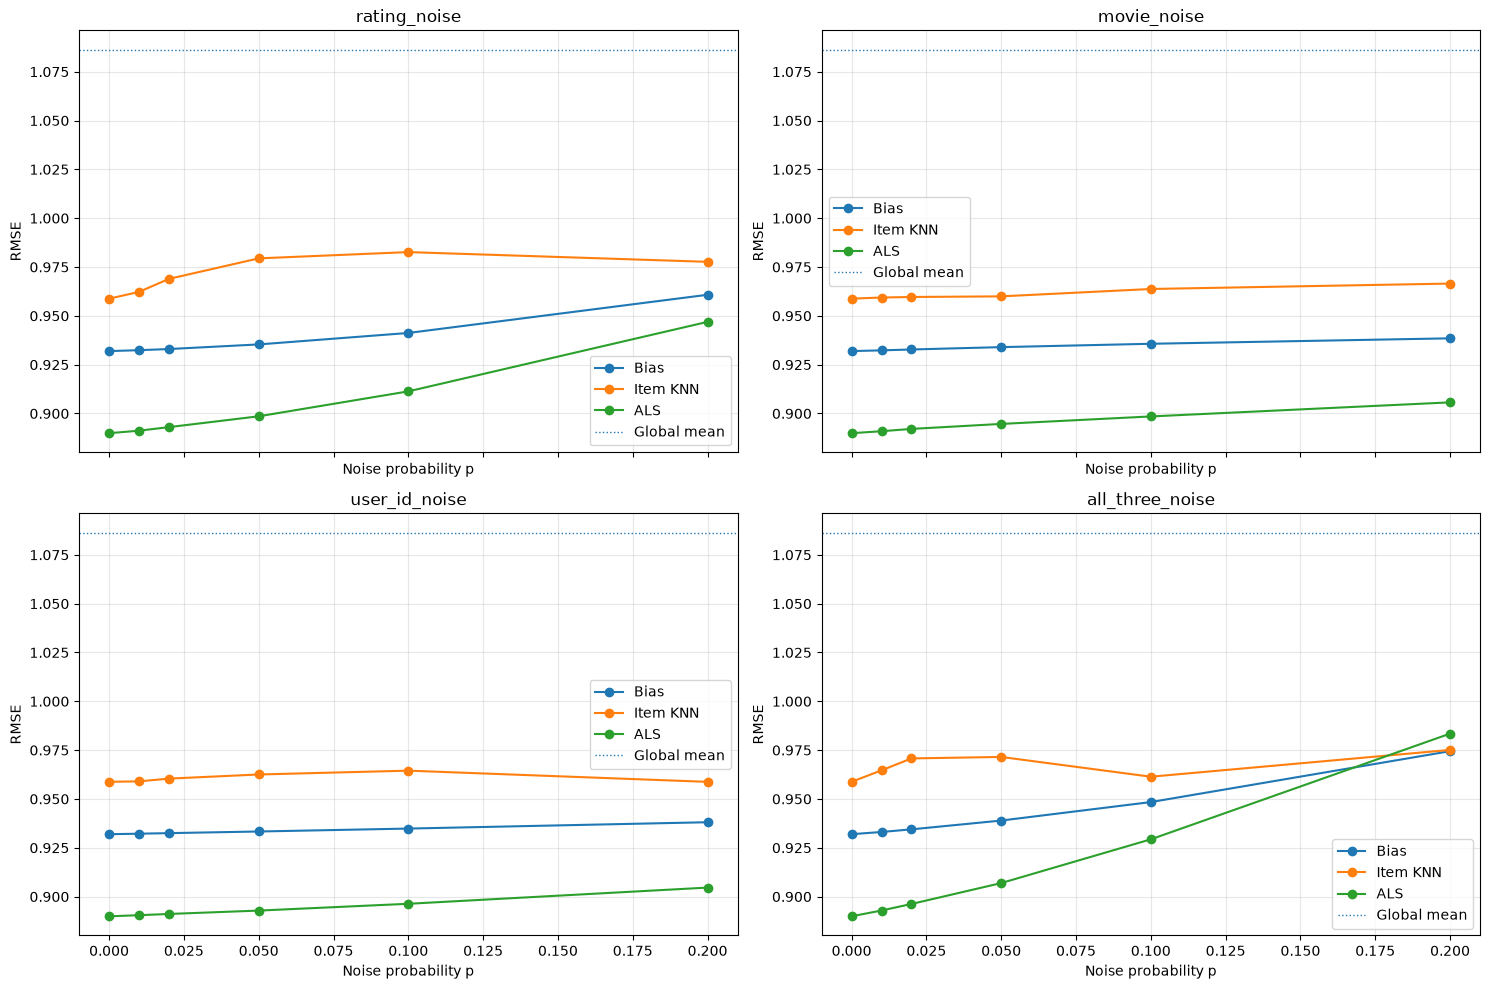

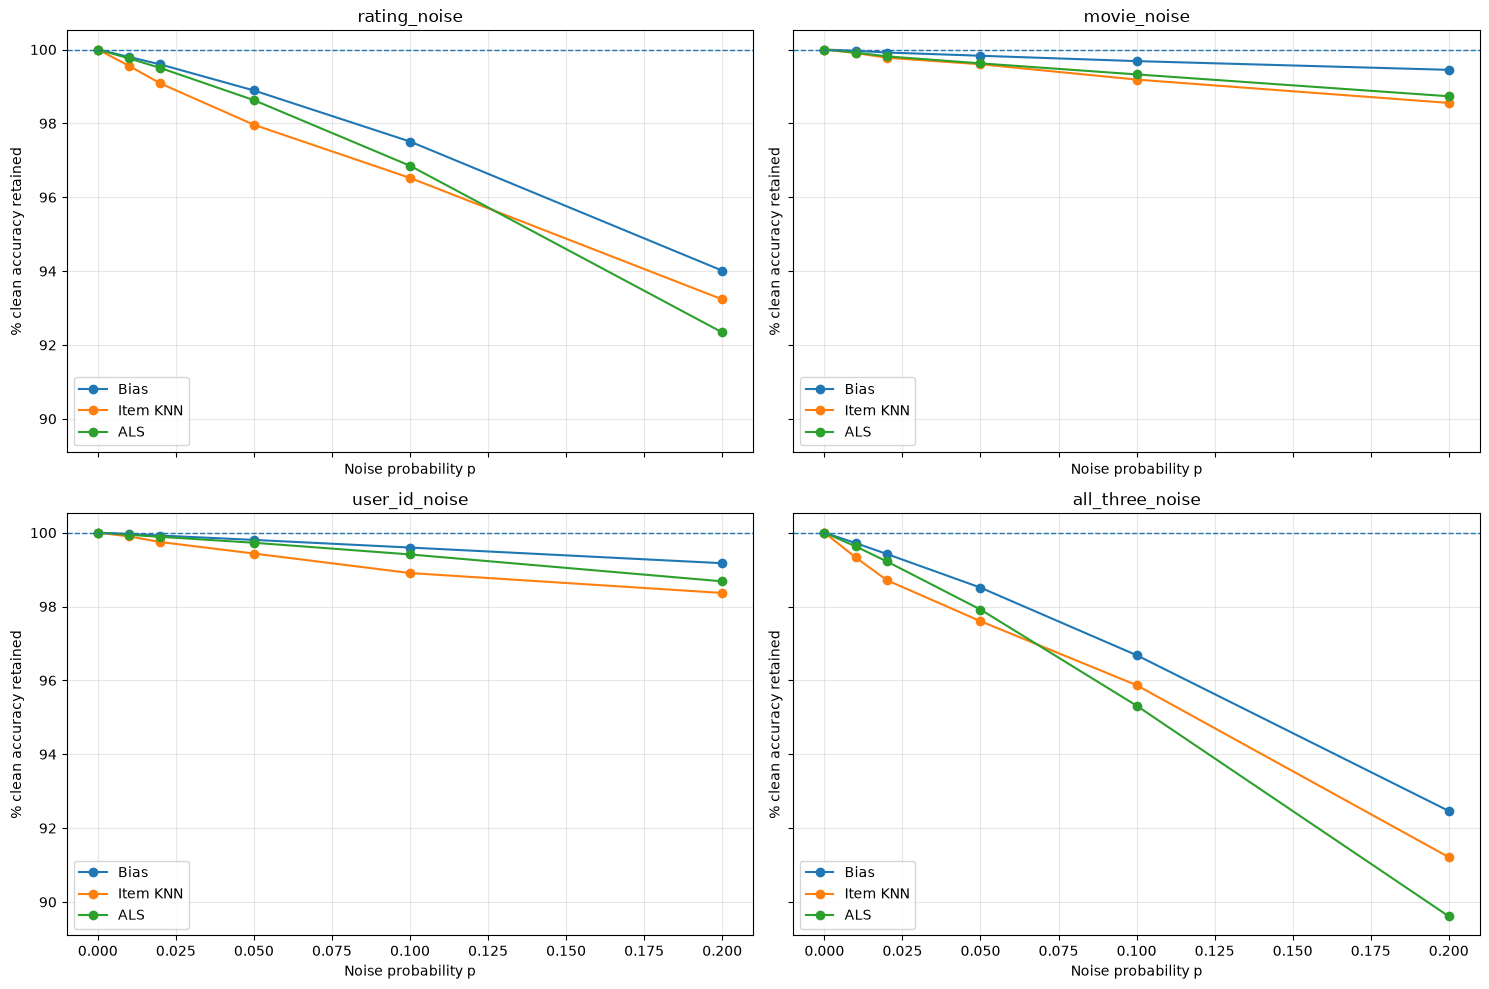

In [121]:
model_order = ["Bias", "Item KNN", "ALS"]

clean_plot = (
    clean_model_comparison
    .set_index("model")
    .loc[model_order]
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].bar(clean_plot["model"], clean_plot["rmse"])
axes[0].axhline(
    global_rmse,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Clean-data RMSE")
axes[0].legend()

axes[1].bar(clean_plot["model"], clean_plot["mae"])
axes[1].axhline(
    global_mae,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[1].set_ylabel("MAE")
axes[1].set_title("Clean-data MAE")
axes[1].legend()

axes[2].bar(
    clean_plot["model"],
    clean_plot["within_1_star_pct"],
)
axes[2].axhline(
    global_within_1,
    linestyle=":",
    linewidth=1,
    label="Global mean",
)
axes[2].set_ylabel("% within 1 star")
axes[2].set_title("Clean-data prediction accuracy")
axes[2].legend()

for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
)

axes = axes.ravel()

for ax, scenario in zip(axes, noise_scenarios):
    part = all_model_summary[
        all_model_summary["scenario"] == scenario
    ]

    for model_name in model_order:
        model_part = part[
            part["model"] == model_name
        ].sort_values("p")

        ax.plot(
            model_part["p"],
            model_part["rmse"],
            marker="o",
            label=model_name,
        )

    ax.axhline(
        global_rmse,
        linestyle=":",
        linewidth=1,
        label="Global mean",
    )

    ax.set_title(scenario)
    ax.set_xlabel("Noise probability p")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for ax, scenario in zip(axes, noise_scenarios):
    part = all_model_summary[
        all_model_summary["scenario"] == scenario
    ]

    for model_name in model_order:
        model_part = part[
            part["model"] == model_name
        ].sort_values("p")

        ax.plot(
            model_part["p"],
            model_part["within_1_star_retained_pct"],
            marker="o",
            label=model_name,
        )

    ax.axhline(100, linestyle="--", linewidth=1)
    ax.set_title(scenario)
    ax.set_xlabel("Noise probability p")
    ax.set_ylabel("% clean accuracy retained")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

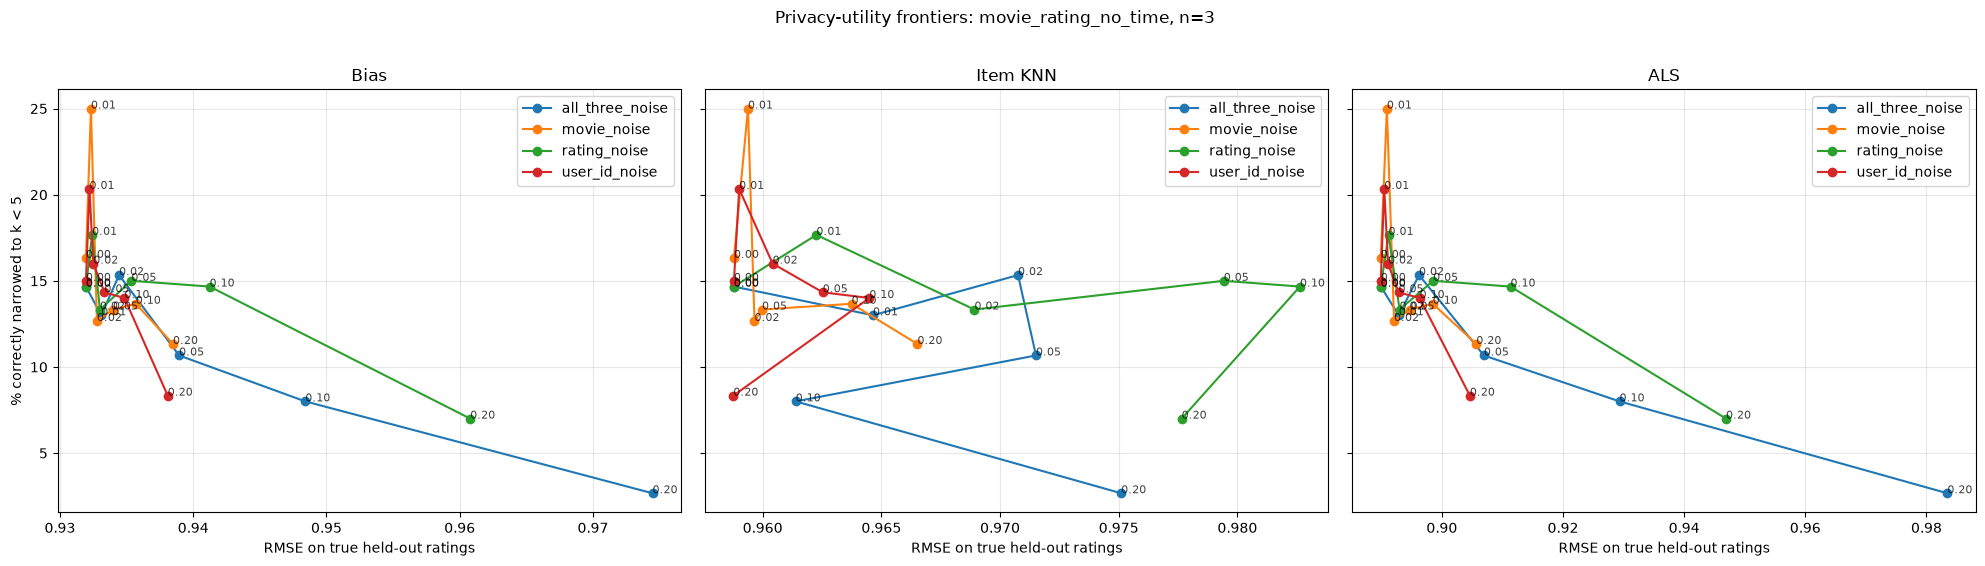

,scenario,p,model,pct_less_than_5_correct,false_positive_rate_among_less_than_5,rmse,mae,within_1_star_pct,within_1_star_retained_pct,rmse_utility_retained_pct
0,all_three_noise,0.00,ALS,14.666667,0.000000,0.889912,0.692534,76.162420,100.000000,100.000000
1,all_three_noise,0.00,Bias,14.666667,0.000000,0.931949,0.733283,73.100706,100.000000,100.000000
2,all_three_noise,0.00,Item KNN,14.666667,0.000000,0.958788,0.725401,74.156586,100.000000,100.000000
3,all_three_noise,0.01,ALS,13.000000,9.302326,0.892887,0.696286,75.879741,99.628847,98.485242
4,all_three_noise,0.01,Bias,13.000000,9.302326,0.933097,0.735475,72.894464,99.717865,99.256384
...,...,...,...,...,...,...,...,...,...,...
67,user_id_noise,0.10,Bias,14.000000,17.647059,0.934838,0.736972,72.805640,99.596358,98.129385
68,user_id_noise,0.10,Item KNN,14.000000,17.647059,0.964492,0.734721,73.345478,98.906223,95.528336
69,user_id_noise,0.20,ALS,8.333333,45.652174,0.904622,0.707133,75.158350,98.681672,92.512093
70,user_id_noise,0.20,Bias,8.333333,45.652174,0.938086,0.740908,72.495820,99.172530,96.025341


Saved combined_privacy_utility_all_recommenders.csv


In [122]:
PLOT_KNOWLEDGE_NAME = "movie_rating_no_time"
PLOT_N_KNOWN = 3

privacy_for_models = noise_summary[
    (noise_summary["knowledge_name"] == PLOT_KNOWLEDGE_NAME)
    & (noise_summary["n_known"] == PLOT_N_KNOWN)
].copy()

privacy_utility_all_models = privacy_for_models.merge(
    all_model_summary,
    on=["scenario", "p"],
    how="left",
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.5),
    sharey=True,
)

for ax, model_name in zip(axes, model_order):
    model_part = privacy_utility_all_models[
        privacy_utility_all_models["model"] == model_name
    ]

    for scenario, scenario_part in model_part.groupby("scenario"):
        scenario_part = scenario_part.sort_values("p")

        ax.plot(
            scenario_part["rmse"],
            scenario_part["pct_less_than_5_correct"],
            marker="o",
            label=scenario,
        )

        for _, row in scenario_part.iterrows():
            ax.annotate(
                f"{row['p']:.2f}",
                (
                    row["rmse"],
                    row["pct_less_than_5_correct"],
                ),
                fontsize=8,
                alpha=0.75,
            )

    ax.set_title(model_name)
    ax.set_xlabel("RMSE on true held-out ratings")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("% correctly narrowed to k < 5")

fig.suptitle(
    f"Privacy-utility frontiers: {PLOT_KNOWLEDGE_NAME}, n={PLOT_N_KNOWN}",
    y=1.02,
)

plt.tight_layout()
plt.show()

display(
    privacy_utility_all_models[[
        "scenario",
        "p",
        "model",
        "pct_less_than_5_correct",
        "false_positive_rate_among_less_than_5",
        "rmse",
        "mae",
        "within_1_star_pct",
        "within_1_star_retained_pct",
        "rmse_utility_retained_pct",
    ]].sort_values(["scenario", "p", "model"])
)

privacy_utility_all_models.to_csv(
    "combined_privacy_utility_all_recommenders.csv",
    index=False,
)

print("Saved combined_privacy_utility_all_recommenders.csv")